# Frame & Topic Analysis

### Imports/Data

In [13]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [14]:
#load data

#full_df = pd.read_parquet('merged_topic_and_frames_filtered.parquet') # Original 9 sources
full_df = pd.read_parquet('merged_topic_and_frames_filtered_with_time_and_frames.parquet') # Expanded 22 sources

full_df.head()

,uuid,url,outlet_name,bias,date,content,content_preprocessed,topic_top1,topic_top1_score,topic_top2,...,frame_fairness,frame_health,frame_legality,frame_morality,frame_policy,frame_political,frame_public_op,frame_quality_life,frame_regulation,frame_security
0,11362746988981500303,https://www.huffpost.com/entry/cancer-debunkin...,HuffPost,Left,2017-03-13,The term “integrative therapies” describes the...,The term “integrative therapies” describes the...,healthcare,0.981742,Russia,...,0,1,0,0,1,0,0,1,0,0
1,2813003261424375394,https://www.huffpost.com/archive/ca/entry/mich...,HuffPost,Left,2015-02-10,"AMC\nFor Canadian actor Michael Mando, lightni...","AMC\nFor Canadian actor Michael Mando, lightni...",entertainment,0.900575,crime,...,0,0,0,0,0,0,0,1,0,0
2,13243574870888809612,https://www.huffpost.com/entry/walking-dead-se...,HuffPost,Left,2019-07-19,"SAN DIEGO ― Heading into Season 10, the only t...","SAN DIEGO ― Heading into Season 10, the only t...",entertainment,0.765275,pandemic,...,0,0,0,0,1,0,1,1,0,1
3,4340615711027464742,https://www.huffpost.com/entry/trump-military-...,HuffPost,Left,2017-01-19,WASHINGTON ― Part of being a great president i...,WASHINGTON ― Part of being a great president i...,elections and politics,0.865624,technology,...,0,0,1,0,1,0,0,0,1,1
4,15731527146425700041,https://www.huffpost.com/entry/coronavirus-sec...,HuffPost,Left,2020-06-17,"Across Europe and much of the United States, t...","Across Europe and much of the United States, t...",entertainment,0.708834,healthcare,...,0,1,1,0,1,0,1,1,1,1


In [15]:
def group_bias(bias):
    if bias in ['Left', 'Lean Left']:
        return 'Left'
    elif bias in ['Right', 'Lean Right']:
        return 'Right'
    else:
        return 'Center'

full_df['bias_grouped'] = full_df['bias'].apply(group_bias)

print(full_df['bias'].value_counts())
print(full_df['bias_grouped'].value_counts())

bias
Left          68051
Right         25030
Center        20370
Lean Right    16112
Lean Left      3963
Name: count, dtype: int64
bias_grouped
Left      72014
Right     41142
Center    20370
Name: count, dtype: int64


In [16]:
left_df = full_df[full_df['bias_grouped'] == 'Left']
right_df = full_df[full_df['bias_grouped'] == 'Right']
center_df = full_df[full_df['bias_grouped'] == 'Center']

print(full_df['outlet_name'].value_counts())

outlet_name
Newsweek                  21579
Vox                       19052
Breitbart News            14671
HuffPost                   9617
New York Post              8424
CNBC                       7957
Vice                       7580
Reuters                    6979
Washington Times           6579
The New Yorker             4014
PJ Media                   3302
Red State                  3253
Slate                      3238
Wall Street Journal        3227
MSNBC                      2971
The Washington Post        2770
BBC News                   2207
The Gateway Pundit         1385
Fox News                   1378
The Guardian               1193
Orange County Register     1109
Townhall                   1041
Name: count, dtype: int64


In [17]:
summary_df = (
    full_df.groupby('outlet_name')
    .agg(
        Total_Articles=('outlet_name', 'size'),
        Bias_Label=('bias', 'first')
    )
    .reset_index()
    .rename(columns={
        'outlet_name': 'Outlet',
        'Total_Articles': 'Total Articles',
        'Bias_Label': 'Bias Label'
    })
    .sort_values('Total Articles', ascending=False)
)

summary_df.style.hide(axis='index')

Outlet,Total Articles,Bias Label
Newsweek,21579,Left
Vox,19052,Left
Breitbart News,14671,Right
HuffPost,9617,Left
New York Post,8424,Lean Right
CNBC,7957,Center
Vice,7580,Left
Reuters,6979,Center
Washington Times,6579,Lean Right
The New Yorker,4014,Left


### Map Frames & Biases

In [18]:
# Find the mapping from vector positions to frame names
frame_mapping = {}

for idx, row in full_df.iterrows():
    frames = row['frames']
    vector = row['vector']
    
    # Convert arrays
    if isinstance(frames, np.ndarray):
        frames = frames.tolist()
    if isinstance(vector, np.ndarray):
        vector = vector.tolist()
    
    # Run through
    frame_idx = 0
    for i, val in enumerate(vector):
        if val == 1:
            frame_mapping[i] = frames[frame_idx]
            frame_idx += 1

# Get list and map
ordered_frame_names = [frame_mapping[i] for i in sorted(frame_mapping.keys())]

print(ordered_frame_names)
print(frame_mapping)

['cap&res', 'crime', 'culture', 'economic', 'fairness', 'health', 'legality', 'morality', 'policy', 'political', 'public_op', 'quality_life', 'regulation', 'security']
{5: 'health', 8: 'policy', 11: 'quality_life', 1: 'crime', 2: 'culture', 10: 'public_op', 13: 'security', 6: 'legality', 12: 'regulation', 0: 'cap&res', 3: 'economic', 4: 'fairness', 9: 'political', 7: 'morality'}


In [19]:
# Colors by party bias
color_map = {
    'Left':'#0015BC',           # Blue (Dem blue)
    'Lean Left': '#6BA3D3',      # Light blue
    'Center': '#808080',         # Grey
    'Lean Right': '#E8A1A1',     # Light red
    'Right': '#E81B23'           # Red (GOP red)
}

column_order = ['Left', 'Lean Left', 'Center', 'Lean Right', 'Right']

topic_list = full_df['topic_top1'].unique()

### Topics Over Time by Bias

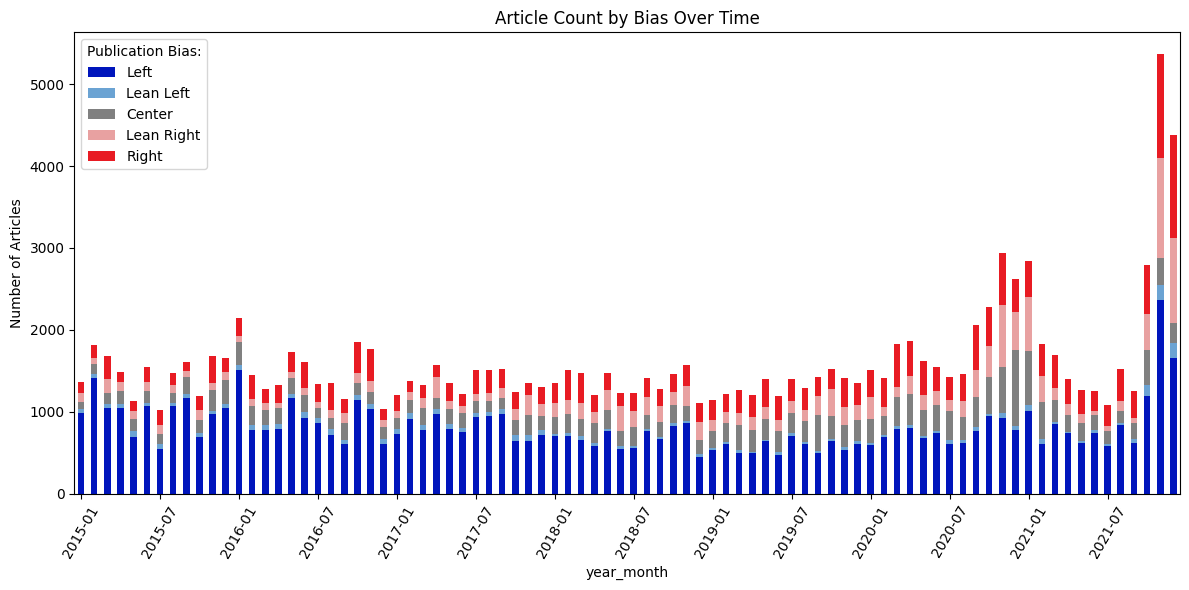

In [20]:
# Count Summary by Bias
bias_counts = full_df.groupby(['year_month', 'bias']).size().unstack(fill_value=0)
bias_counts = bias_counts.reindex(columns=column_order, fill_value=0)

# Plot
bias_counts.plot(kind='bar', stacked=True, figsize=(12, 6), color=[color_map[bias] for bias in bias_counts.columns])

plt.ylabel('Number of Articles')
plt.title('Article Count by Bias Over Time')
plt.legend(title='Publication Bias:')
plt.xticks(range(0, len(bias_counts), 6), bias_counts.index[::6],rotation=60)
plt.tight_layout()
plt.show()

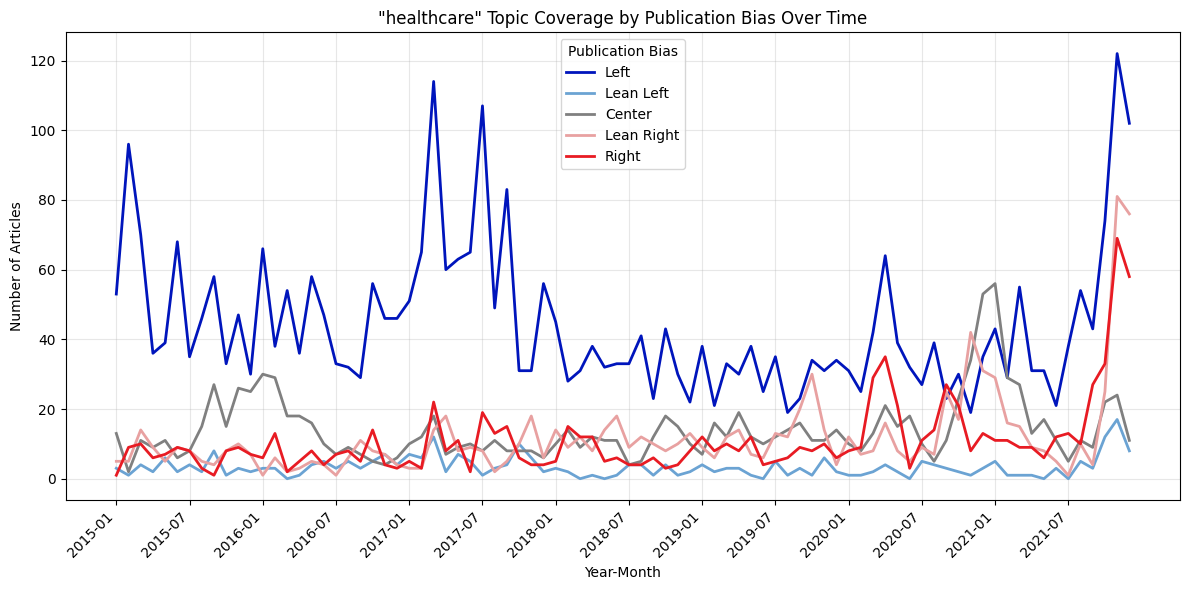

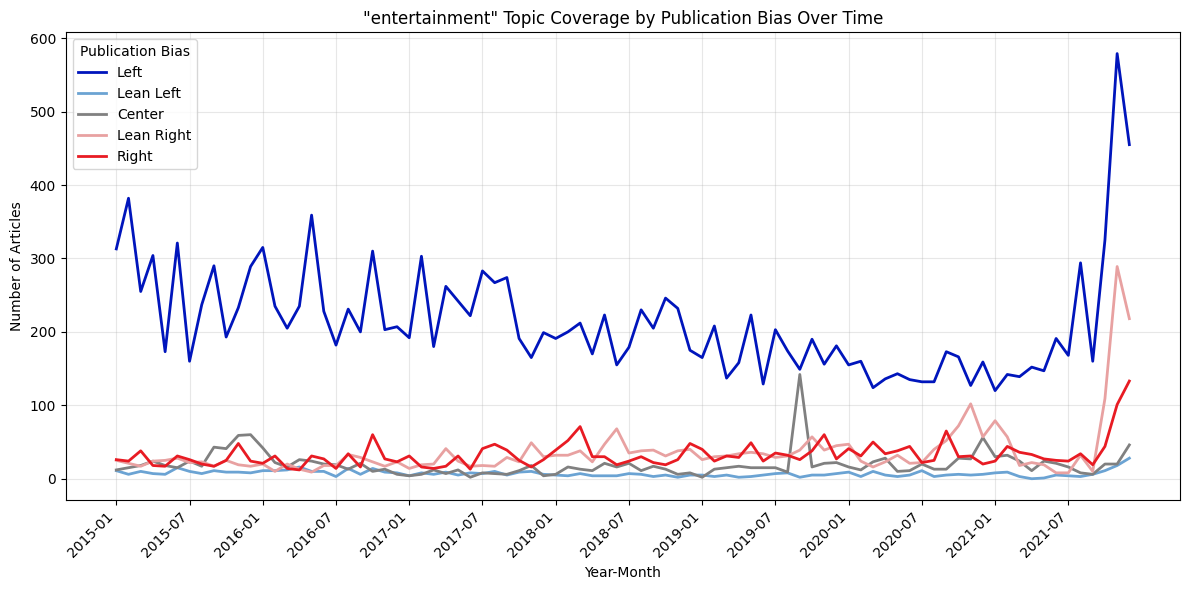

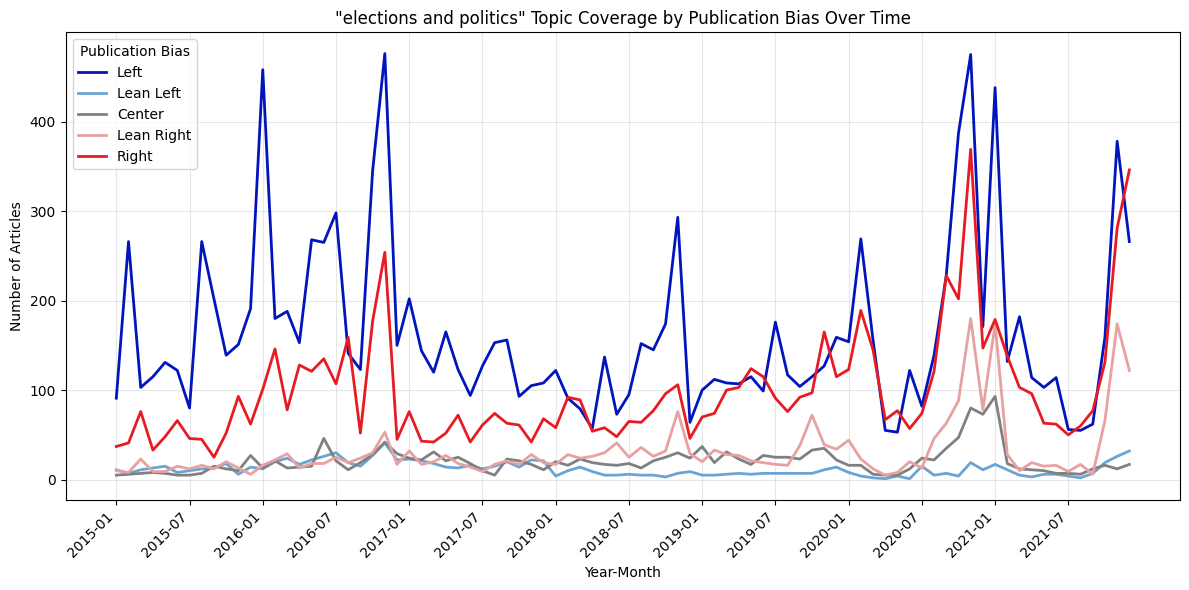

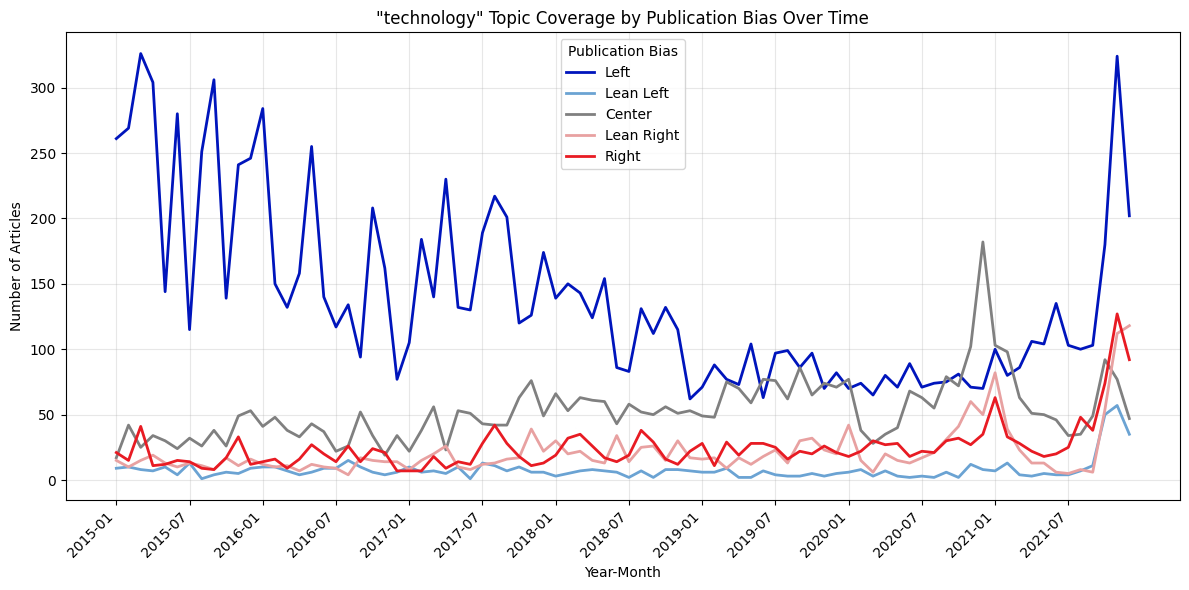

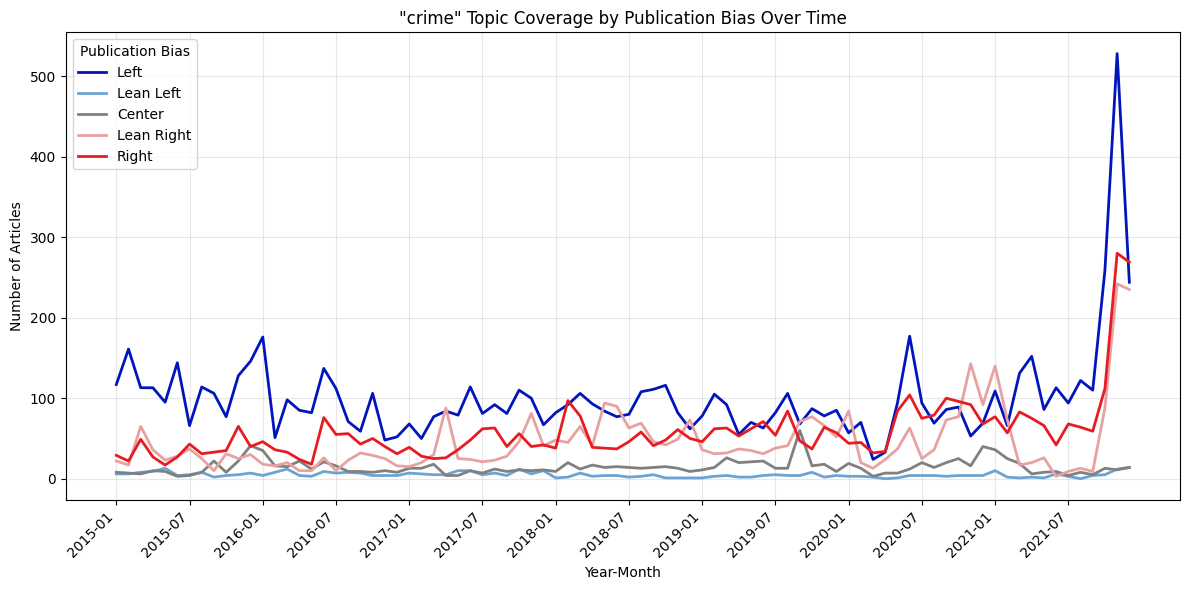

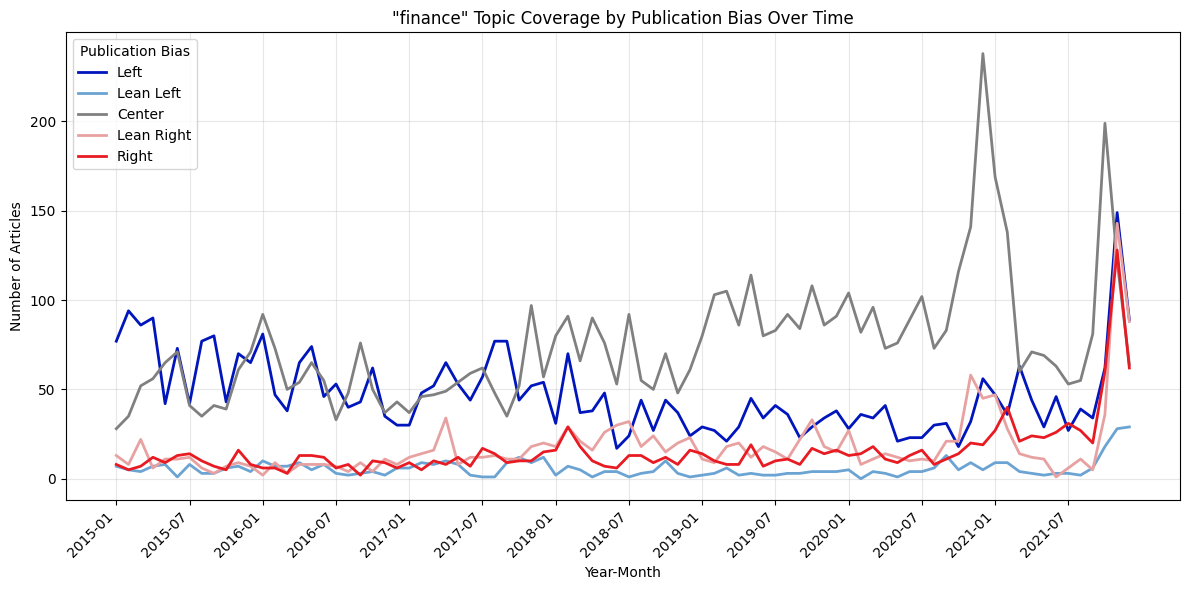

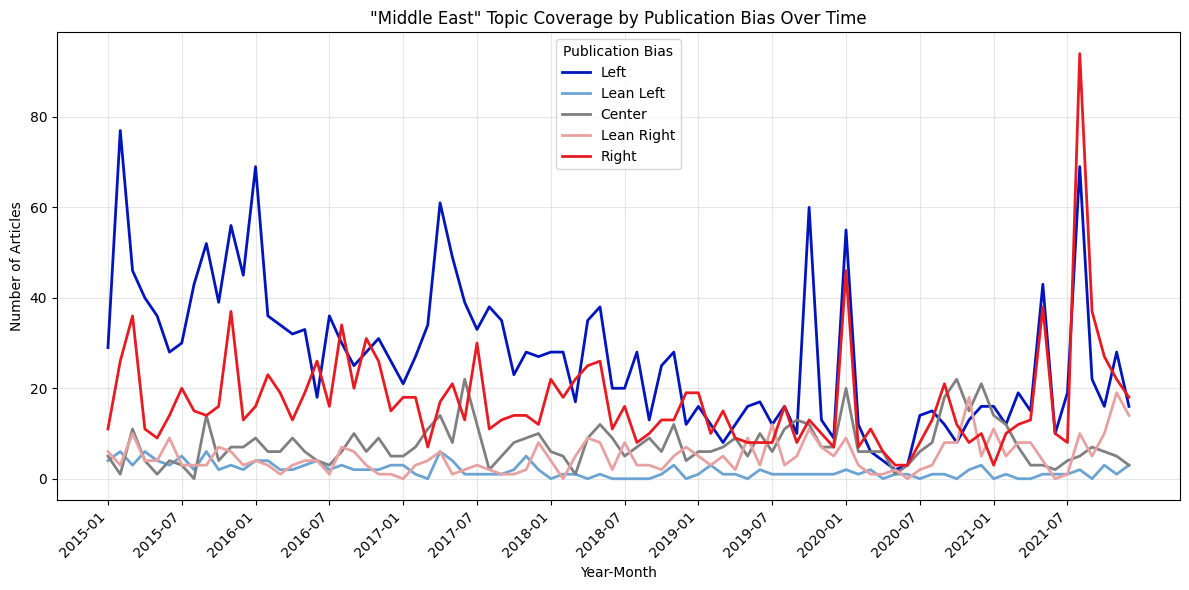

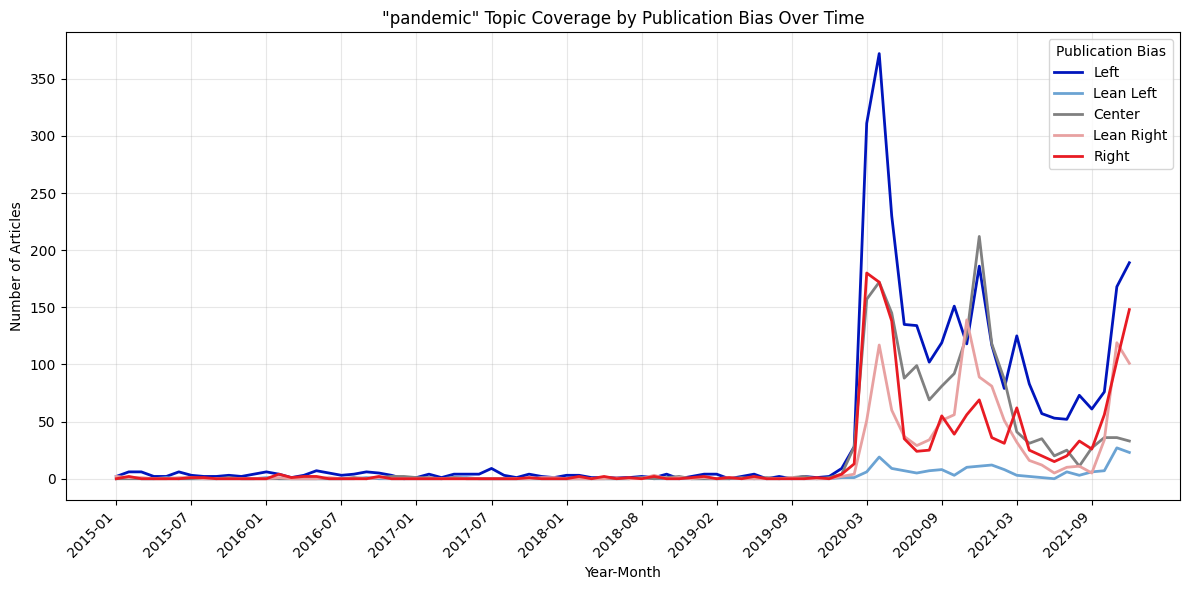

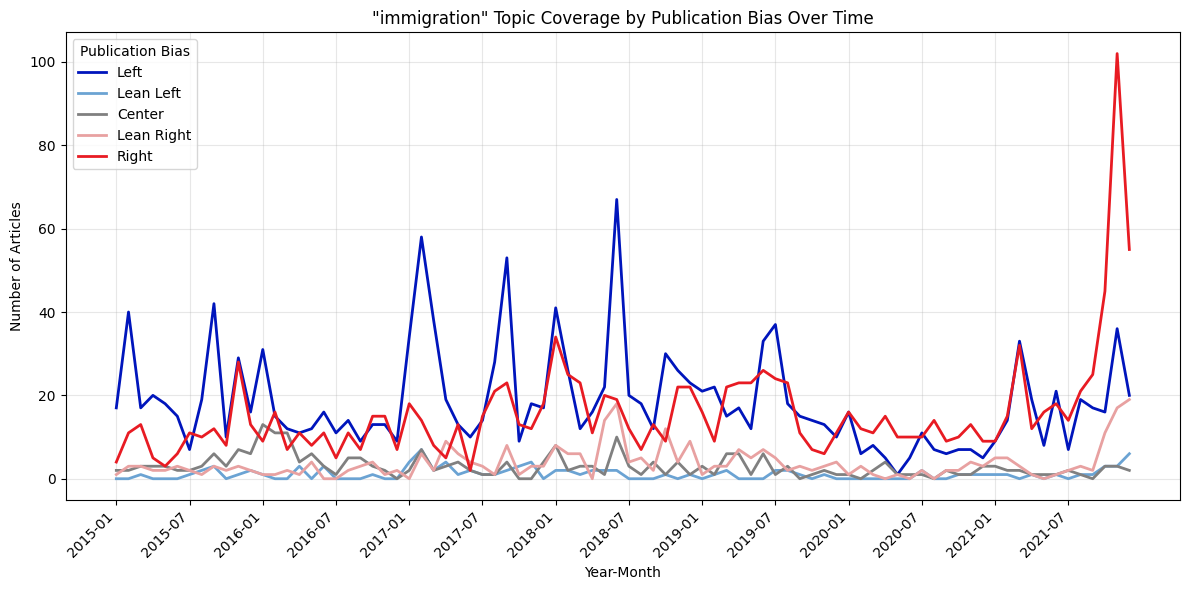

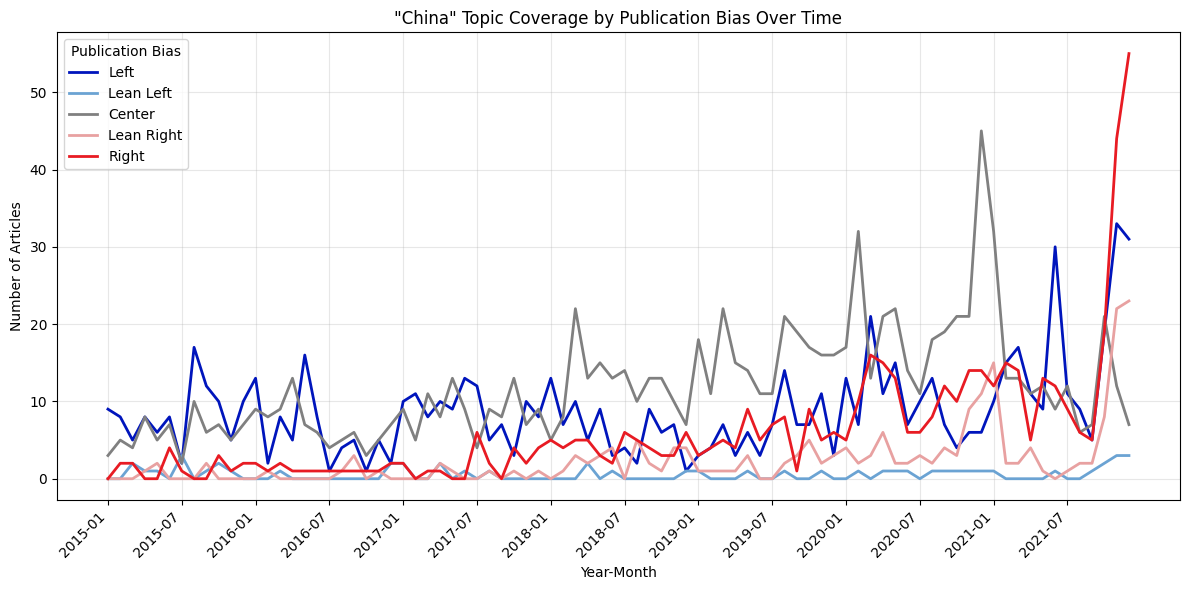

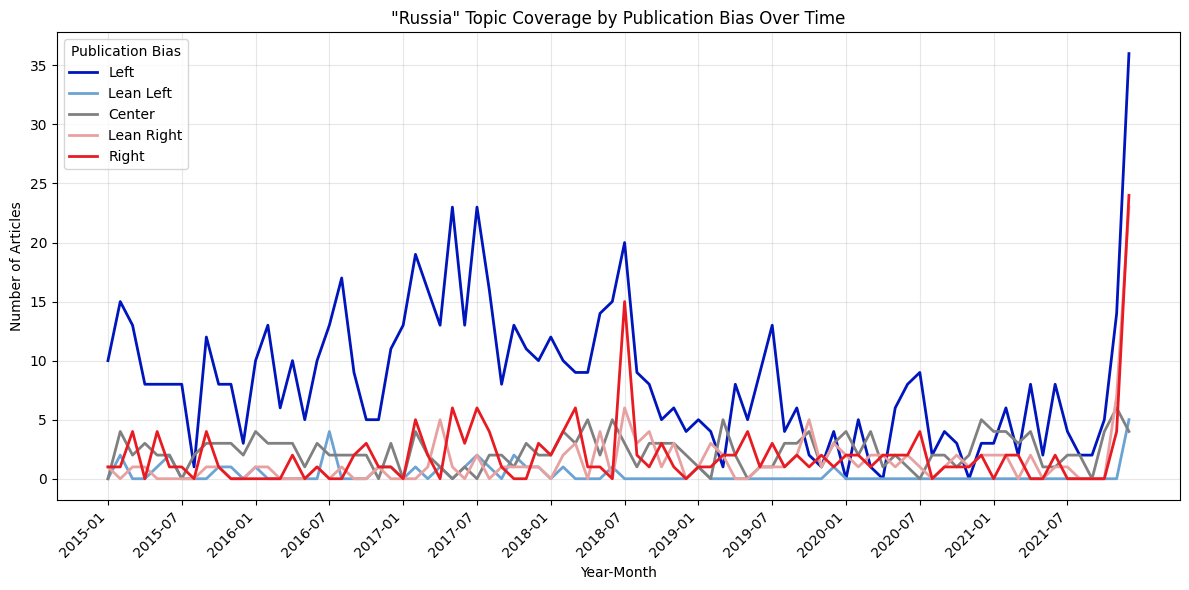

In [21]:
# Loop through topics, produce simple viz

for topic in topic_list:

    # Get counts by bias and time
    topic_df = full_df[full_df['topic_top1'] == topic]
    topic_counts = topic_df.groupby(['year_month', 'bias']).size().unstack(fill_value=0)

    # Reorder columns
    topic_counts = topic_counts.reindex(columns=column_order, fill_value=0)
    topic_counts.index = topic_counts.index.astype(str)

    # Plot
    plt.figure(figsize=(12, 6))
    for bias in topic_counts.columns:
        plt.plot(topic_counts.index, topic_counts[bias], label=bias, color=color_map[bias], linewidth=2)

    plt.xlabel('Year-Month')
    plt.ylabel('Number of Articles')
    plt.title(f'"{topic}" Topic Coverage by Publication Bias Over Time')
    plt.legend(title='Publication Bias')
    plt.xticks(range(0, len(topic_counts), 6), topic_counts.index[::6], rotation=45, ha='right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### Frame & Topic Co-Occurence

##### Frame-Frame Occurences

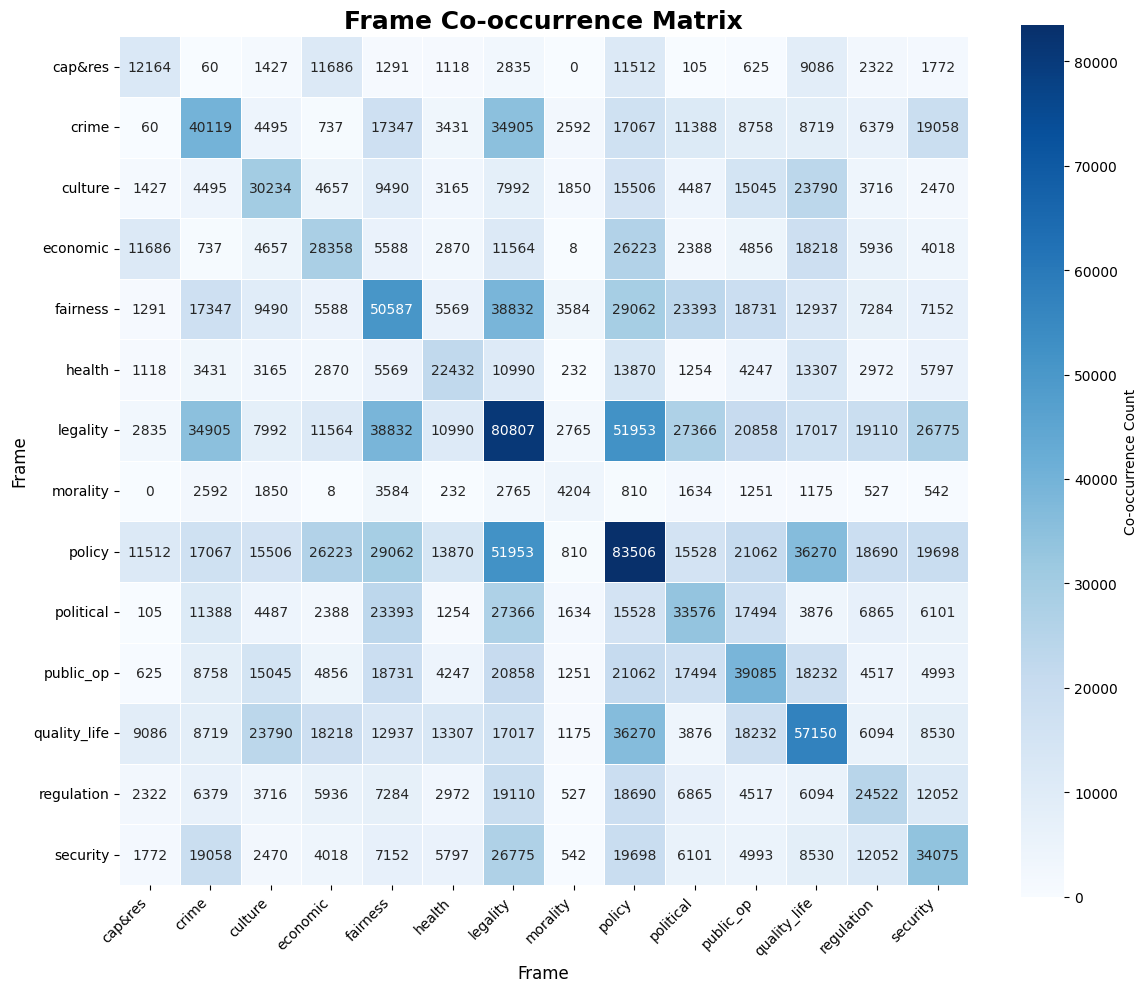

In [22]:
# Frame Co-Occurence & FrameTopic Co-Occurence Matrices

def create_frame_cooccur_matrix(df_subset, frame_names):
    n_frames = len(frame_names)
    co_occur_matrix = np.zeros((n_frames, n_frames))
    
    for idx, row in df_subset.iterrows():
        vector = row['vector']
        
        present_frames = [i for i, val in enumerate(vector) if val == 1]
        
        for i in present_frames:
            for j in present_frames:
                co_occur_matrix[i, j] += 1

    return pd.DataFrame(co_occur_matrix, index=frame_names, columns=frame_names)

co_occur_df = create_frame_cooccur_matrix(full_df, ordered_frame_names)

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(co_occur_df, annot=True, fmt='.0f', cmap='Blues', 
            cbar_kws={'label': 'Co-occurrence Count'}, 
            linewidths=0.5, square=True)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Frame', fontsize=12)
plt.title('Frame Co-occurrence Matrix', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

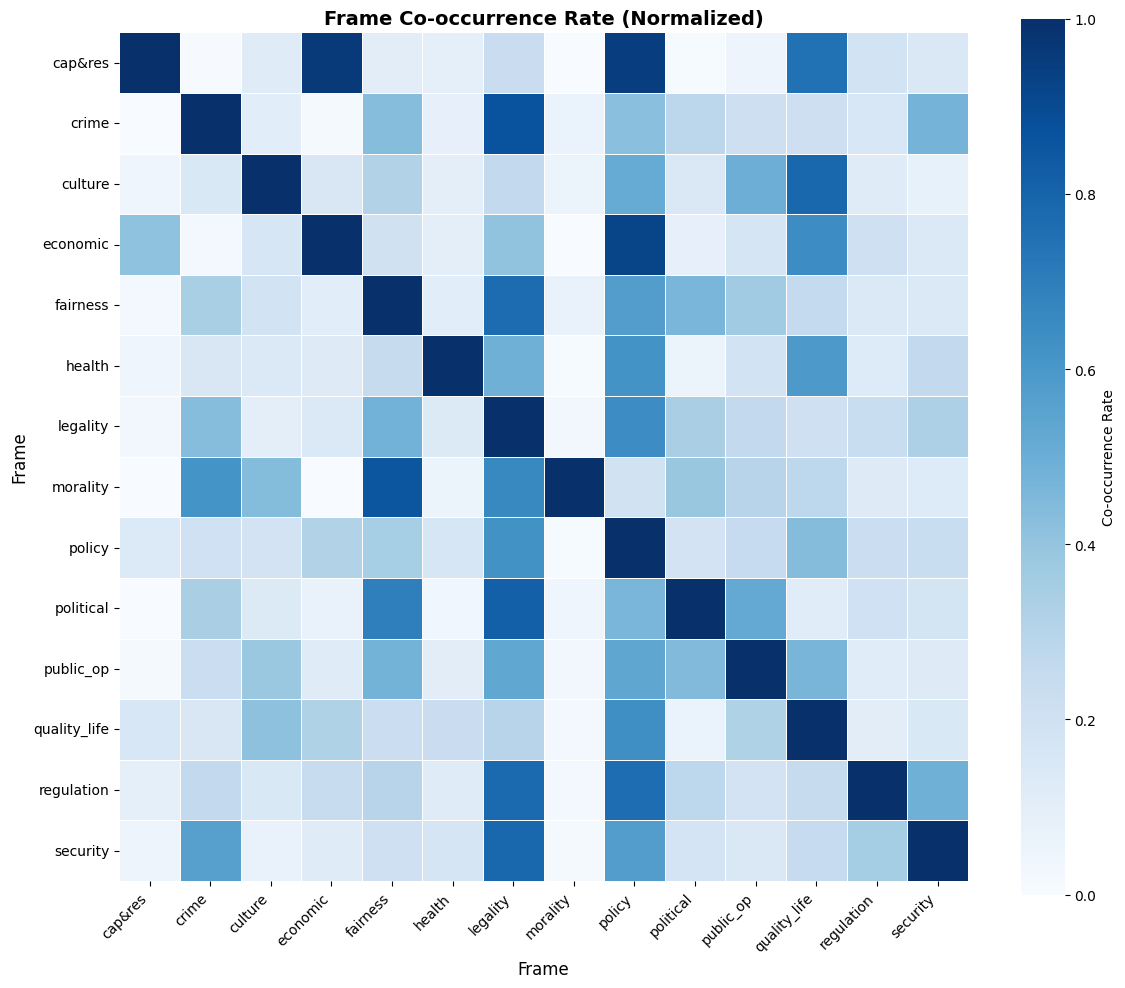

In [23]:
# Take co-occurence matrix and show normalized version
co_occur_normalized = co_occur_df.copy()
n_frames = len(ordered_frame_names)

# Ensure no division by 0
for i in range(n_frames):
    if co_occur_df.iloc[i, i] > 0: 
        co_occur_normalized.iloc[i, :] = co_occur_df.iloc[i, :] / co_occur_df.iloc[i, i]

plt.figure(figsize=(12, 10))
sns.heatmap(co_occur_normalized, annot=False, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, cbar_kws={'label': 'Co-occurrence Rate'}, 
            linewidths=0.5, square=True)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Frame', fontsize=12)
plt.title('Frame Co-occurrence Rate (Normalized)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

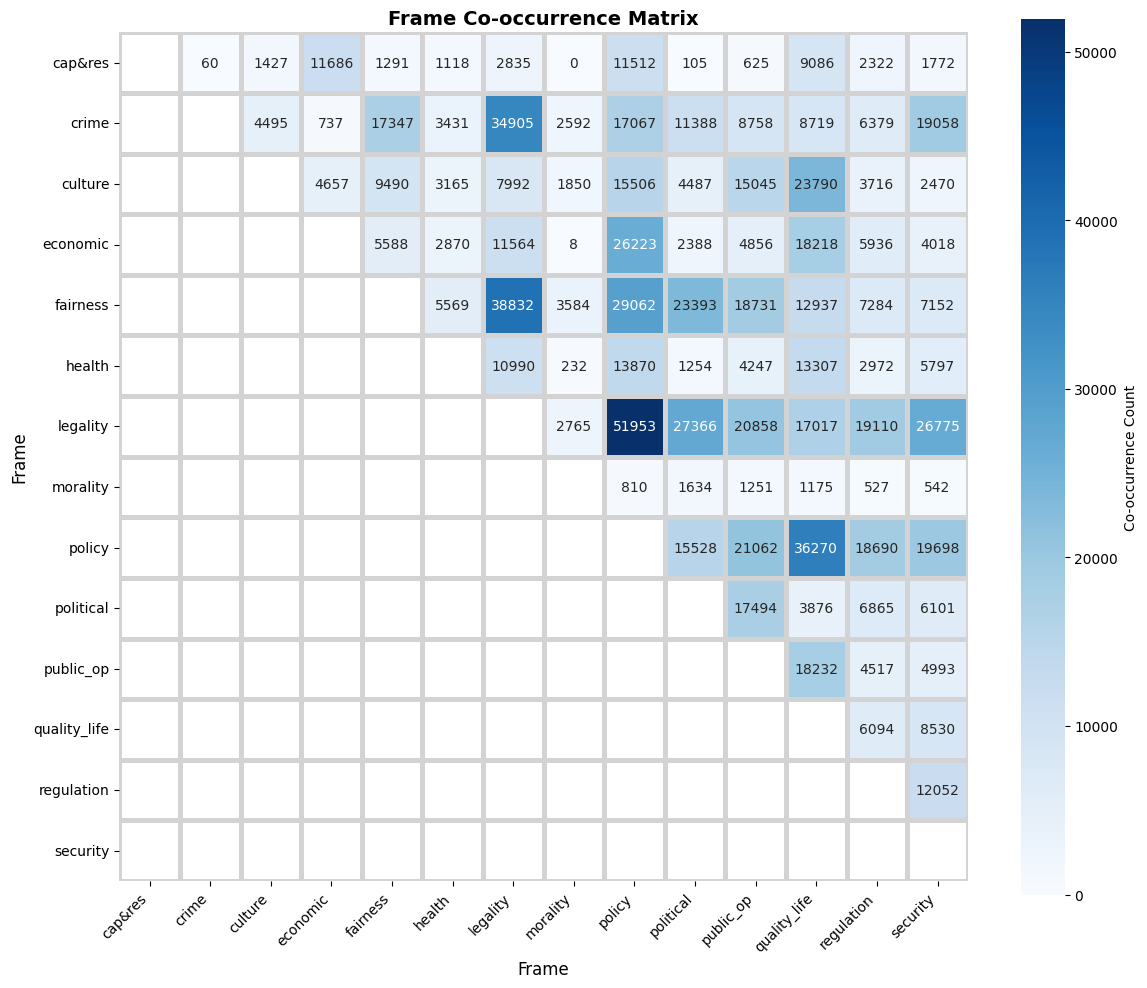

In [24]:
mask = np.tril(np.ones_like(co_occur_df, dtype=bool), k=0)

plt.figure(figsize=(12, 10))
sns.heatmap(co_occur_df, mask=mask, annot=True, fmt='.0f', cmap='Blues', 
            cbar_kws={'label': 'Co-occurrence Count'}, 
            linewidths=2.5, linecolor='lightgrey', square=True)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Frame', fontsize=12)
plt.title('Frame Co-occurrence Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##### Topic-Frame Matrices

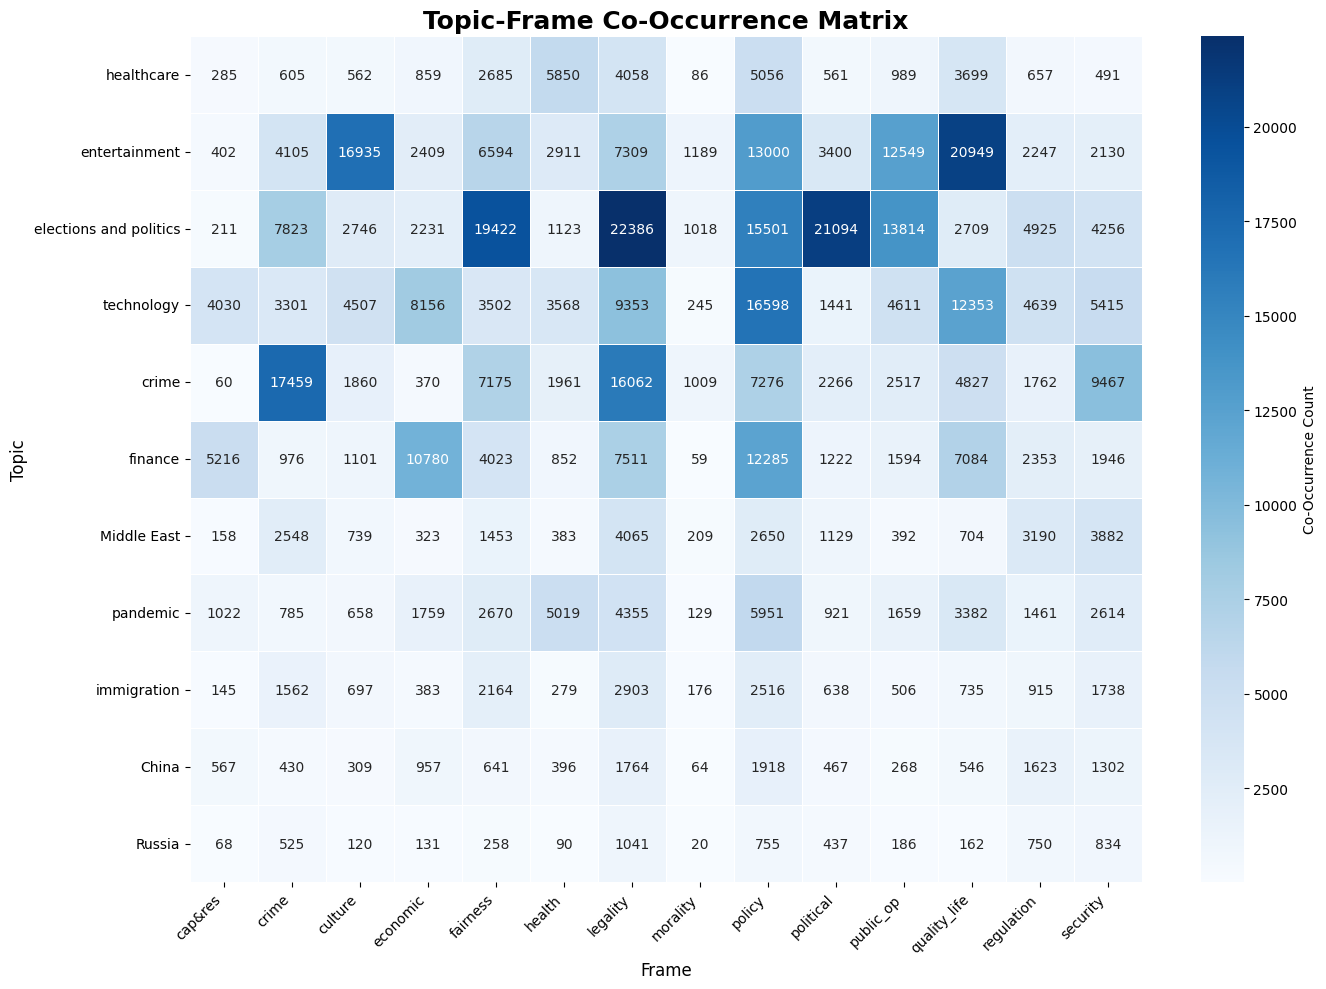

In [25]:
def create_topic_frame_matrix(df_subset, topic_list, frame_names):
    """Create topic-frame co-occurrence matrix for a given dataframe subset"""
    n_topics = len(topic_list)
    n_frames = len(frame_names)
    topic_frame_matrix = np.zeros((n_topics, n_frames))
    
    for idx, row in df_subset.iterrows():
        topic = row['topic_top1']
        vector = row['vector']
        
        # Convert to list if numpy array
        if isinstance(vector, np.ndarray):
            vector = vector.tolist()
        
        # Get topic index
        topic_idx = np.where(topic_list == topic)[0][0]
        
        # Count frame occurrences for this topic
        for frame_idx, val in enumerate(vector):
            if val == 1:
                topic_frame_matrix[topic_idx, frame_idx] += 1
    
    return pd.DataFrame(topic_frame_matrix, index=topic_list, columns=frame_names)

topic_frame_df = create_topic_frame_matrix(full_df, topic_list, ordered_frame_names)

plt.figure(figsize=(14, 10))
sns.heatmap(topic_frame_df, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label': 'Co-Occurrence Count'},
            linewidths=0.5)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.title('Topic-Frame Co-Occurrence Matrix', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##### Topic-Frame Co-Occurence by Bias

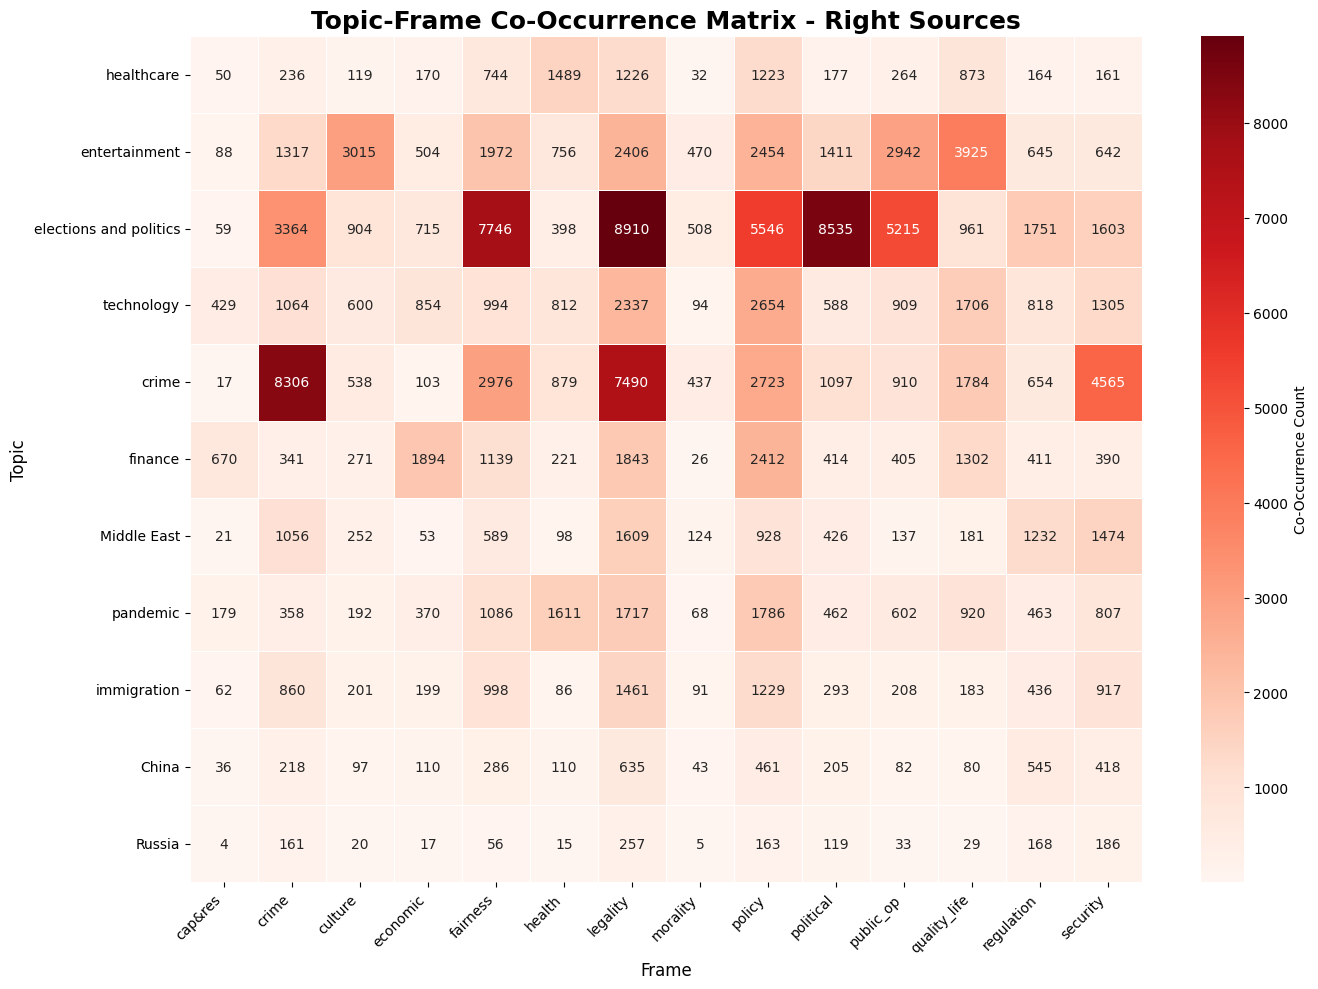

In [26]:
# Right topic-frame co-occurence matrix
right_topic_frame_df = create_topic_frame_matrix(right_df, topic_list, ordered_frame_names)

plt.figure(figsize=(14,10))
sns.heatmap(right_topic_frame_df, annot=True, fmt='.0f', cmap='Reds',
            cbar_kws={'label': 'Co-Occurrence Count'},
            linewidths=0.5)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.title('Topic-Frame Co-Occurrence Matrix - Right Sources', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

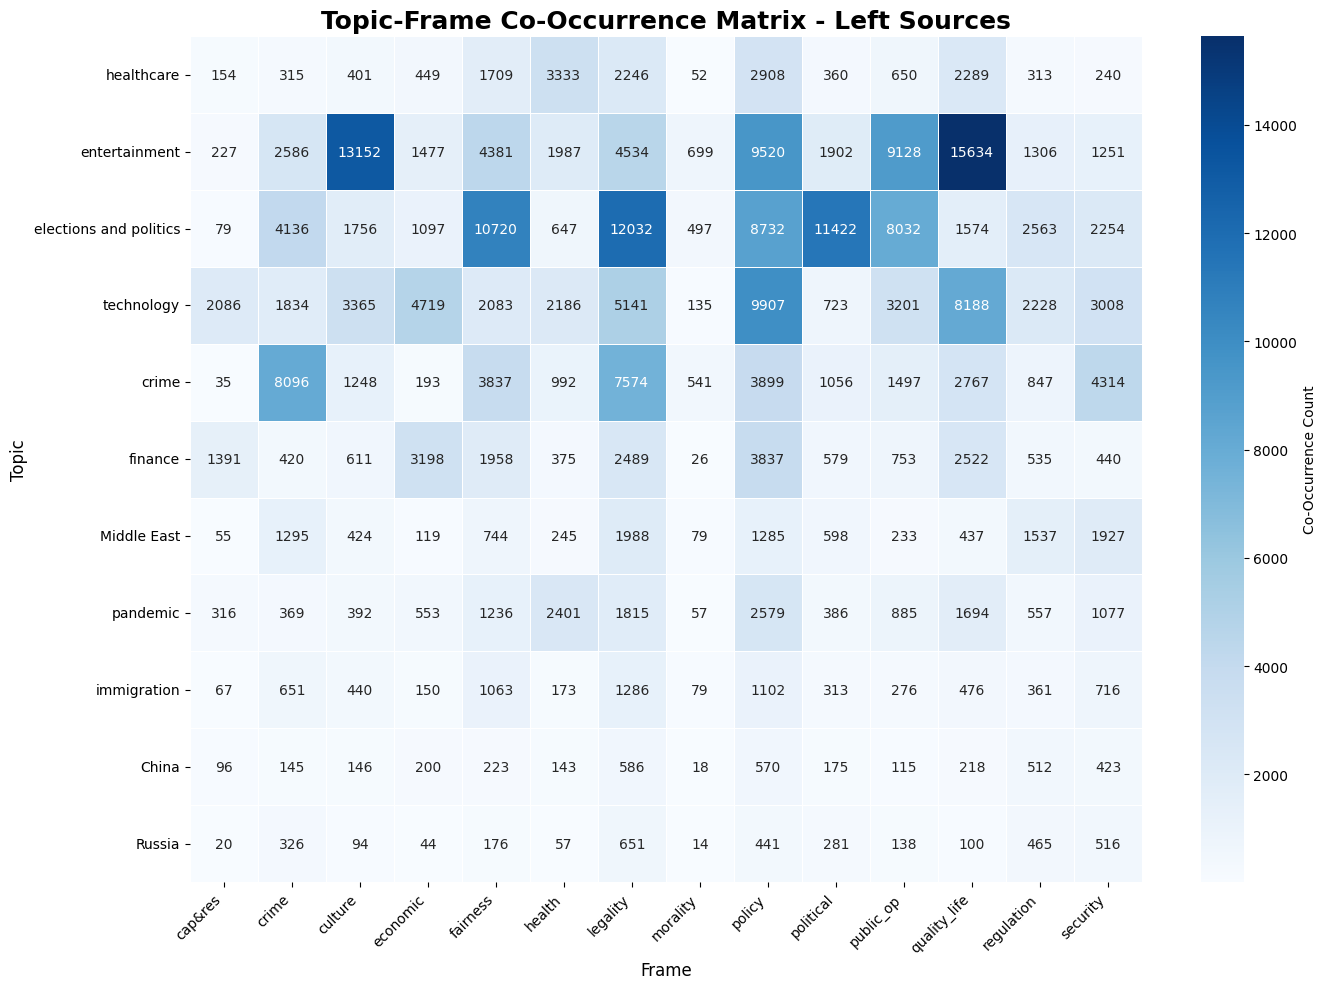

In [27]:
# Left topic-frame co-occurence matrix
left_topic_frame_df = create_topic_frame_matrix(left_df, topic_list, ordered_frame_names)

plt.figure(figsize=(14, 10))
sns.heatmap(left_topic_frame_df, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label': 'Co-Occurrence Count'},
            linewidths=0.5)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.title('Topic-Frame Co-Occurrence Matrix - Left Sources', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


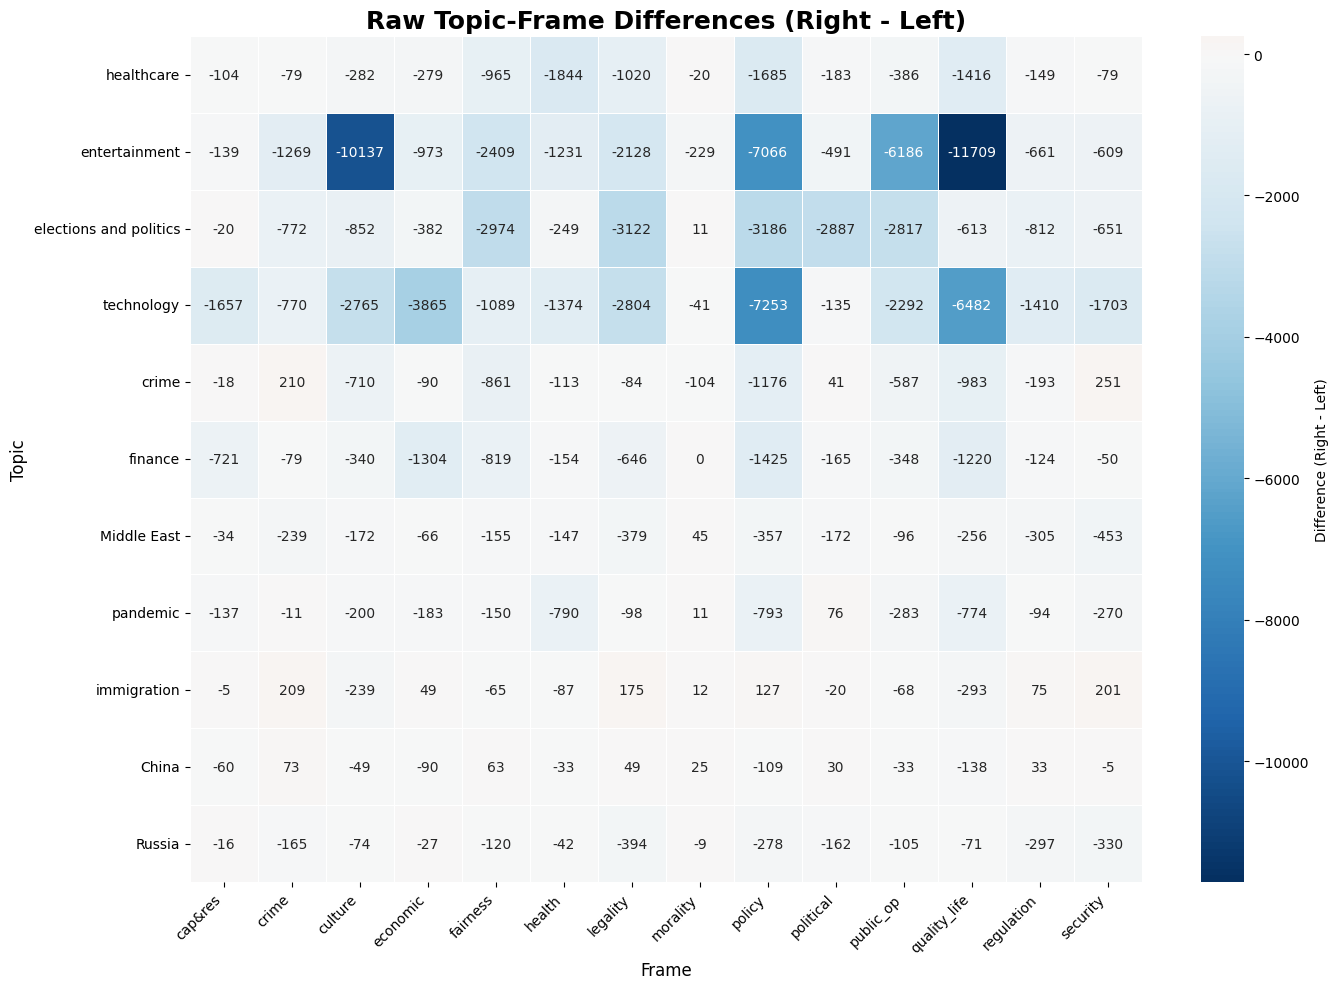

In [28]:
# DIFFERENCE BETWEEN THE TWO - AND SHADE RED/BLUE BASED ON WHICH IS HIGHER
diff_topic_frame_df = right_topic_frame_df - left_topic_frame_df

plt.figure(figsize=(14, 10))
sns.heatmap(diff_topic_frame_df, annot=True, fmt='.0f', cmap='RdBu_r',
            center=0, cbar_kws={'label': 'Difference (Right - Left)'},
            linewidths=0.5)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.title('Raw Topic-Frame Differences (Right - Left)', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

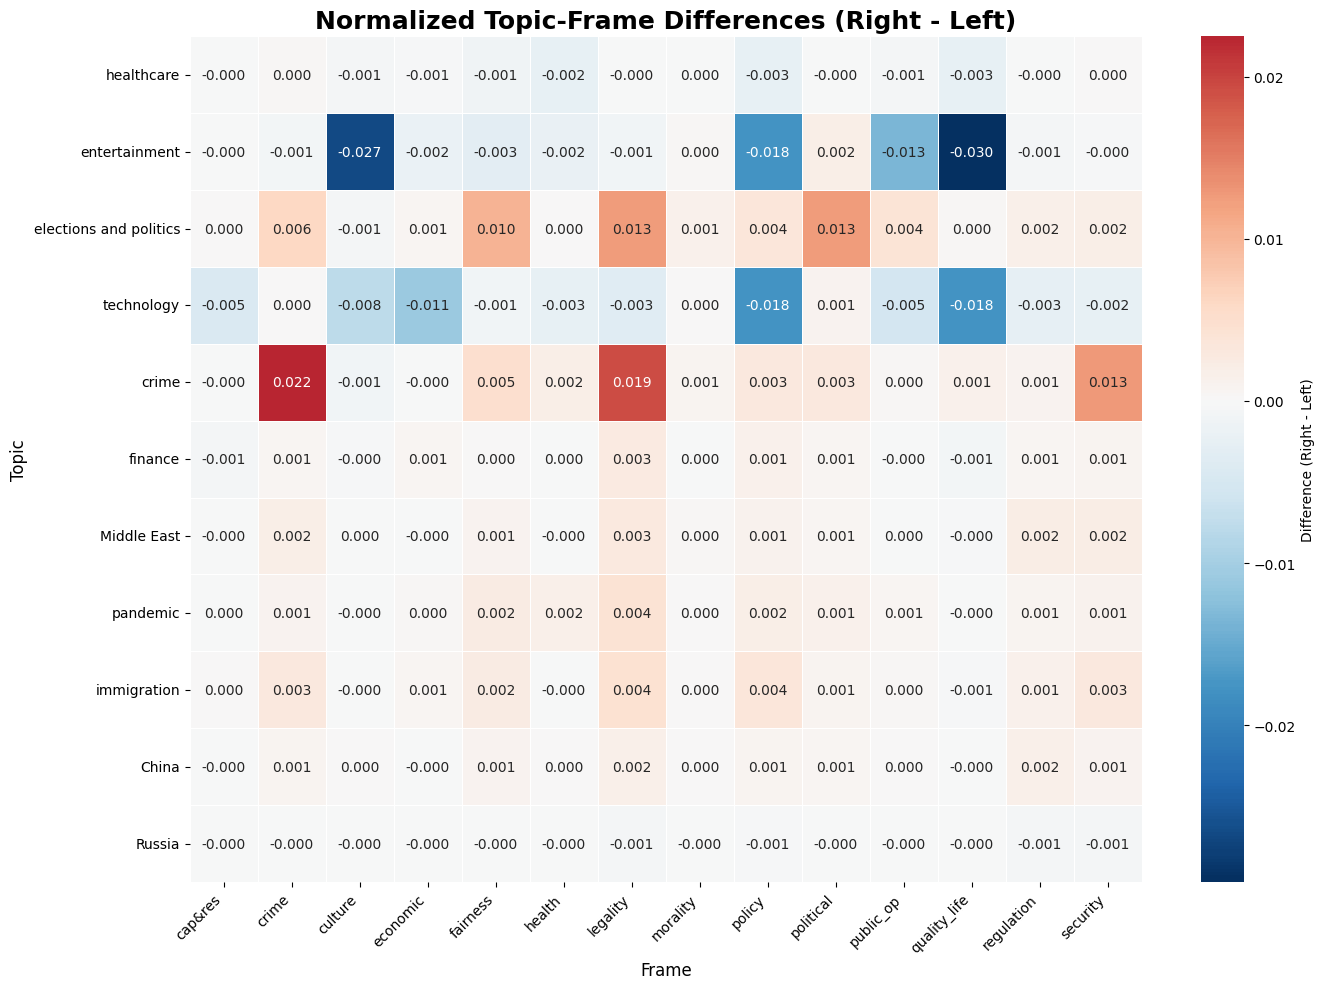

In [29]:
# Normalized differences between right/left topic-frame co-occurence matrices
right_total = right_topic_frame_df.values.sum()
left_total = left_topic_frame_df.values.sum()
diff_normalized_df = (right_topic_frame_df / right_total) - (left_topic_frame_df / left_total)

plt.figure(figsize=(14, 10))
sns.heatmap(diff_normalized_df, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, cbar_kws={'label': 'Difference (Right - Left)'},
            linewidths=0.5)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.title('Normalized Topic-Frame Differences (Right - Left)', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

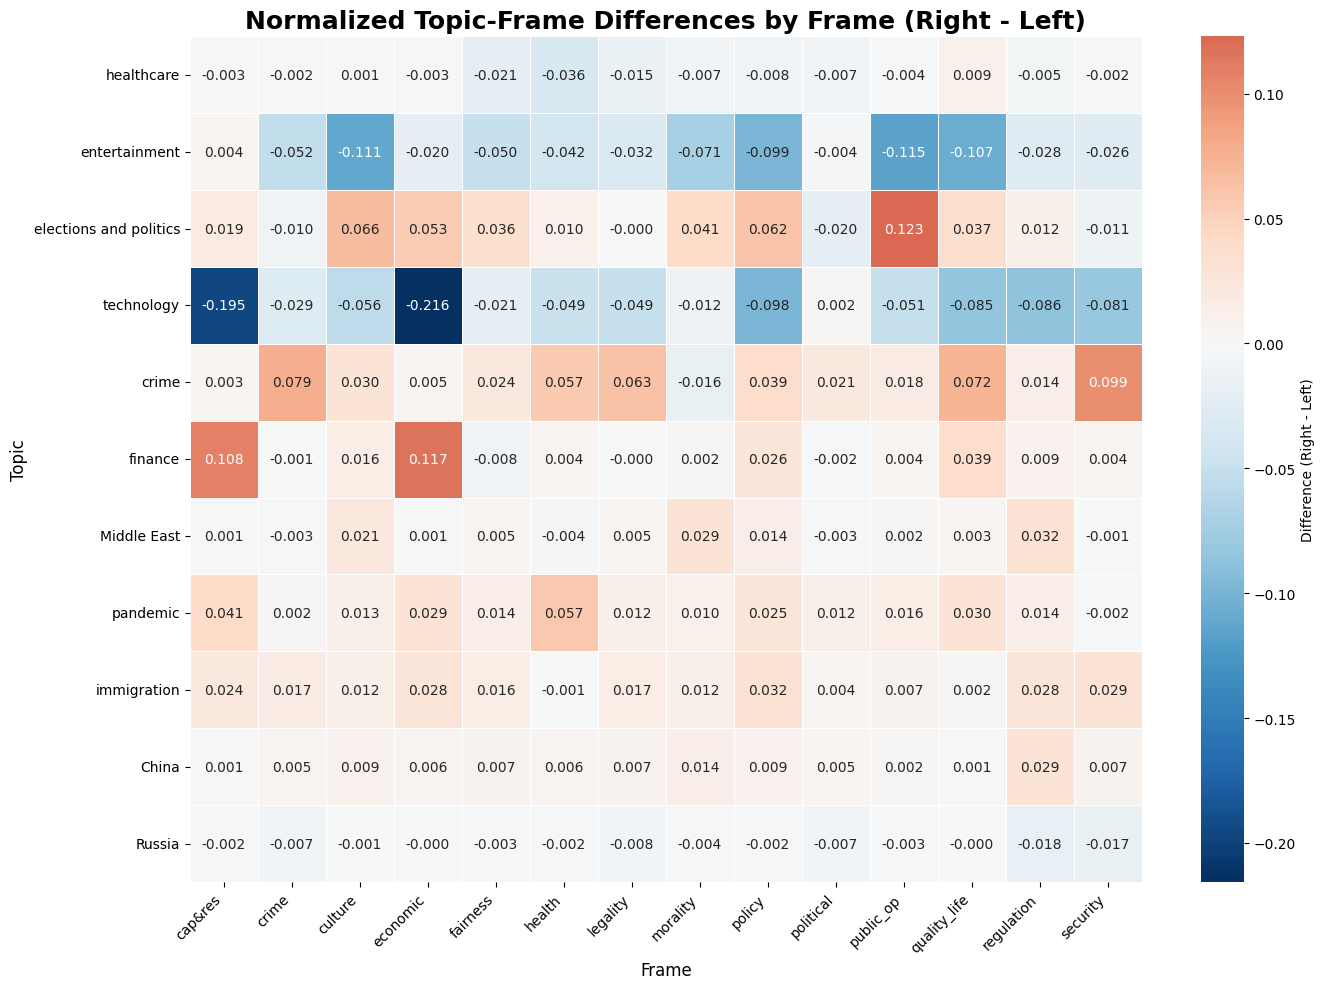

In [30]:
right_normalized_by_frame = right_topic_frame_df / right_topic_frame_df.sum(axis=0)
left_normalized_by_frame = left_topic_frame_df / left_topic_frame_df.sum(axis=0)

# Calculate difference
diff_normalized_by_frame = right_normalized_by_frame - left_normalized_by_frame

plt.figure(figsize=(14, 10))
sns.heatmap(diff_normalized_by_frame, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, cbar_kws={'label': 'Difference (Right - Left)'},
            linewidths=0.5)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.title('Normalized Topic-Frame Differences by Frame (Right - Left)', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

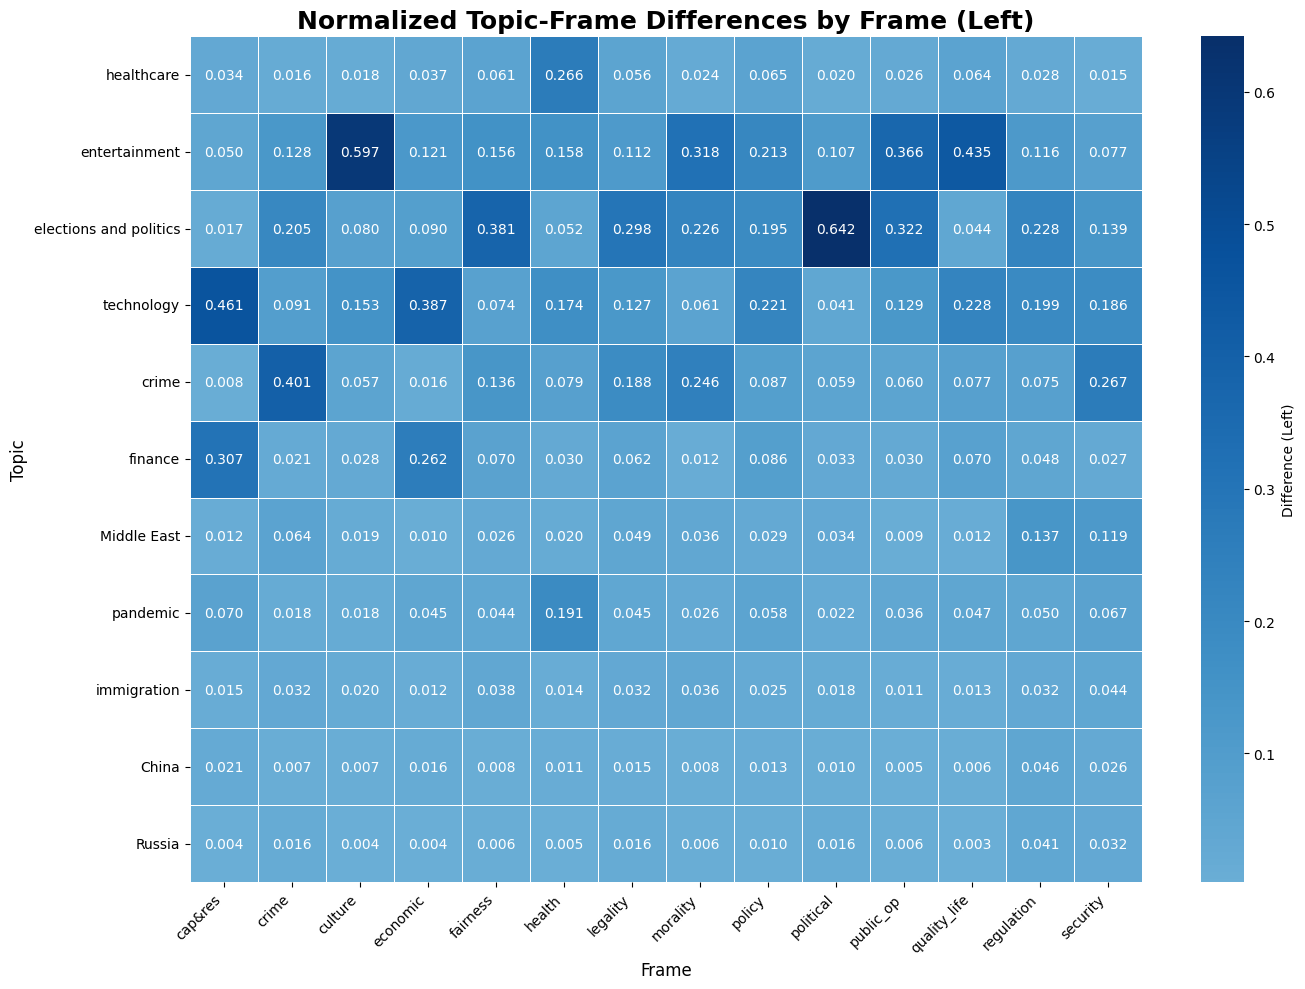

In [31]:
plt.figure(figsize=(14, 10))
sns.heatmap(left_normalized_by_frame, annot=True, fmt='.3f', cmap='Blues',
            center=0, cbar_kws={'label': 'Difference (Left)'},
            linewidths=0.5)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.title('Normalized Topic-Frame Differences by Frame (Left)', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

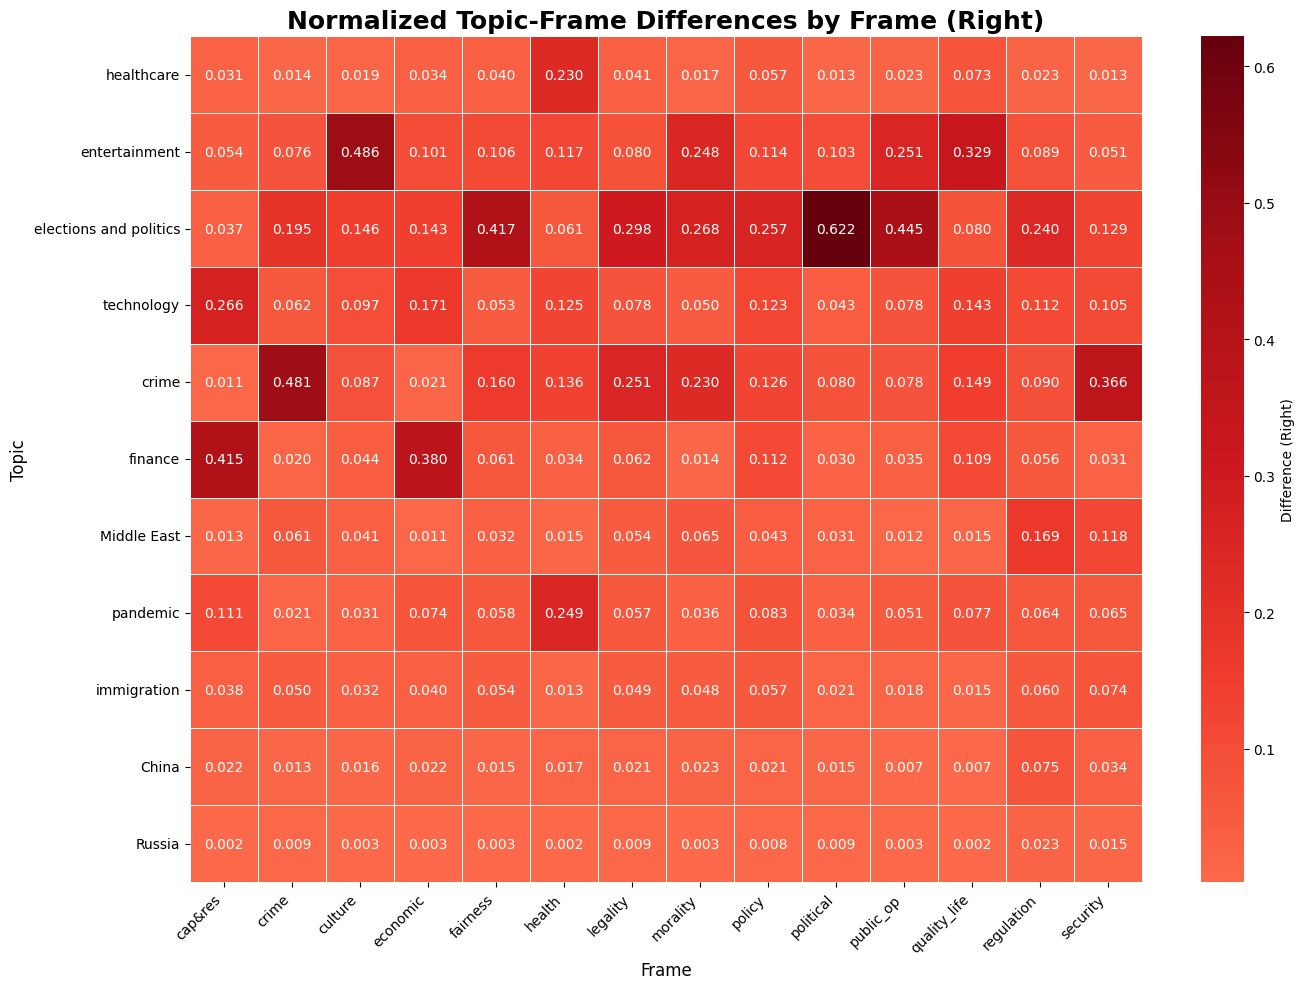

In [32]:
plt.figure(figsize=(14, 10))
sns.heatmap(right_normalized_by_frame,annot=True, fmt='.3f', cmap='Reds',
            center=0, cbar_kws={'label': 'Difference (Right)'},
            linewidths=0.5)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.title('Normalized Topic-Frame Differences by Frame (Right)', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
# Show the % a given topic uses a frame by bias over time, quarterly data



##### Topic-Topic Connections

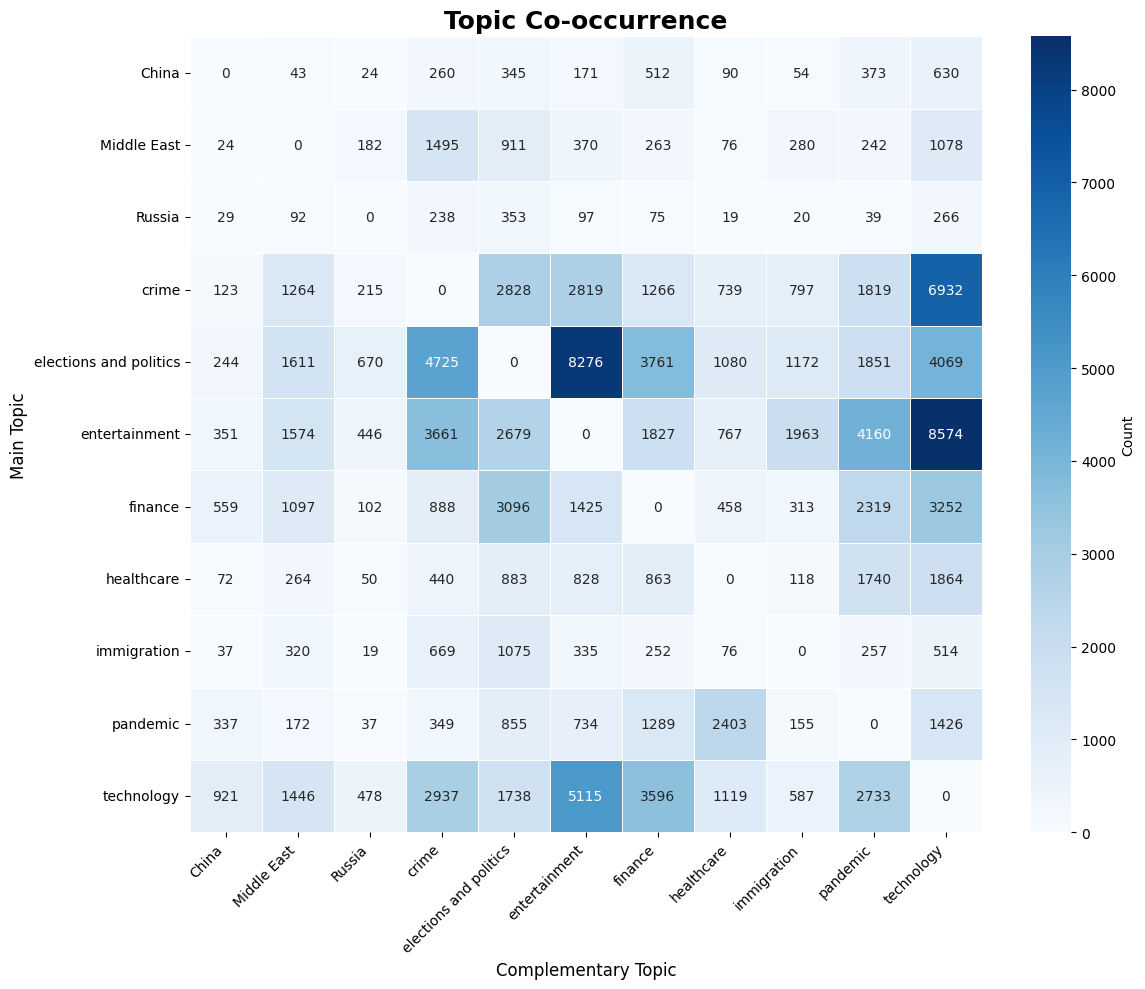

In [34]:
# Network style? how do we want to show? when topic_top1 is X, what are topic_top2 and topic_top3? and should those only be counted if >0.1? 

topic_crosstab = pd.crosstab(full_df['topic_top1'], full_df['topic_top2'])

plt.figure(figsize=(12, 10))
sns.heatmap(topic_crosstab, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label': 'Count'},
            linewidths=0.5)
plt.xlabel('Complementary Topic', fontsize=12)
plt.ylabel('Main Topic', fontsize=12)
plt.title('Topic Co-occurrence', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


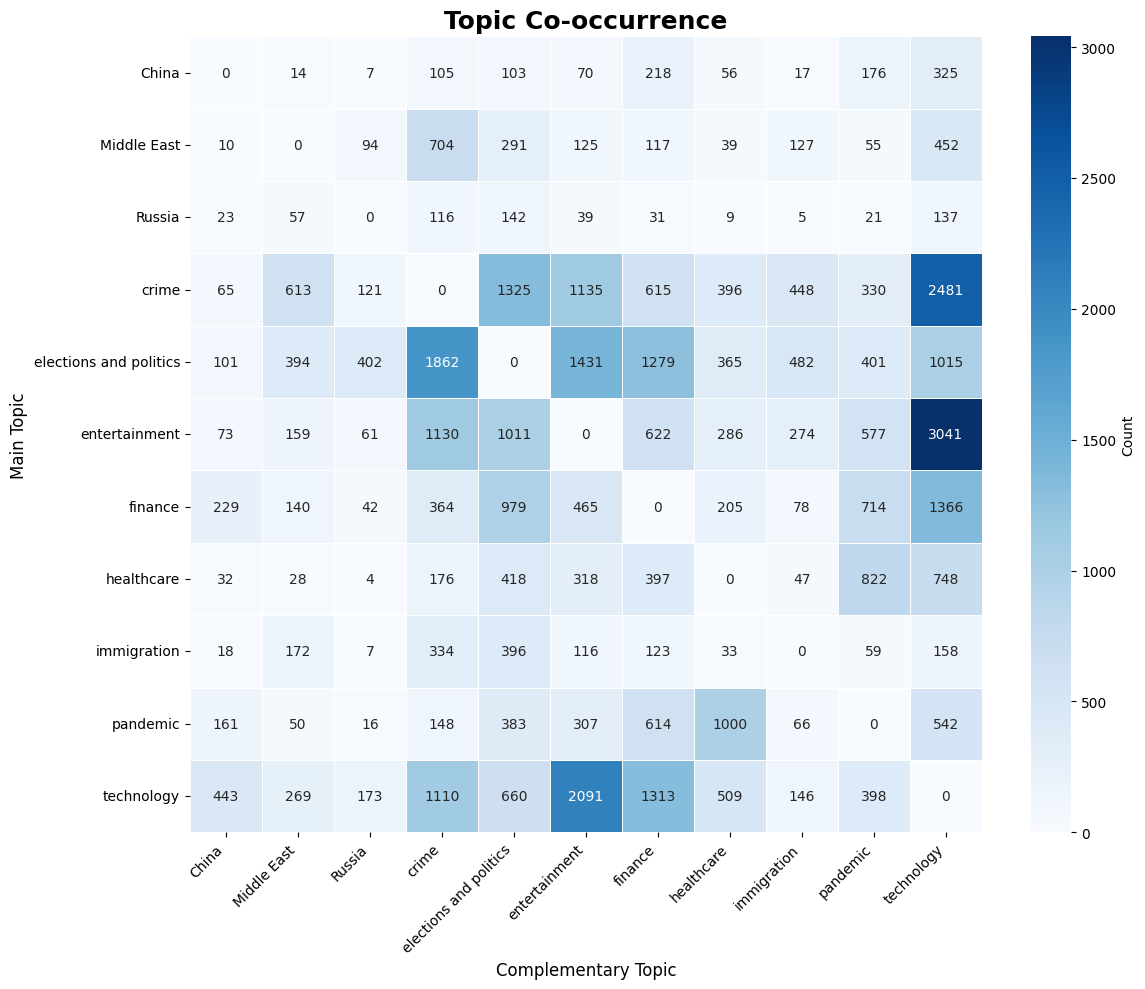

In [35]:
topic2_filtered_df = full_df[full_df['topic_top2_score'] >= 0.1]
topic_crosstab_high2 = pd.crosstab(topic2_filtered_df['topic_top1'], topic2_filtered_df['topic_top2'])

plt.figure(figsize=(12, 10))
sns.heatmap(topic_crosstab_high2, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label': 'Count'},
            linewidths=0.5)
plt.xlabel('Complementary Topic', fontsize=12)
plt.ylabel('Main Topic', fontsize=12)
plt.title('Topic Co-occurrence', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
topic_crosstab.loc['Total'] = topic_crosstab.sum()
topic_crosstab_high2.loc['Total'] = topic_crosstab_high2.sum()

topic_comparison = pd.DataFrame({
    'All 2nd Topics': topic_crosstab.loc['Total'],
    'Significant 2nd Topics (>=0.1)': topic_crosstab_high2.loc['Total']
}).T

topic_comparison.head()


topic_top2,China,Middle East,Russia,crime,elections and politics,entertainment,finance,healthcare,immigration,pandemic,technology
All 2nd Topics,2697,7883,2223,15662,14763,20170,13704,6827,5459,15533,28605
Significant 2nd Topics (>=0.1),1155,1896,927,6049,5708,6097,5329,2898,1690,3553,10265


### Network Analysis of Topics

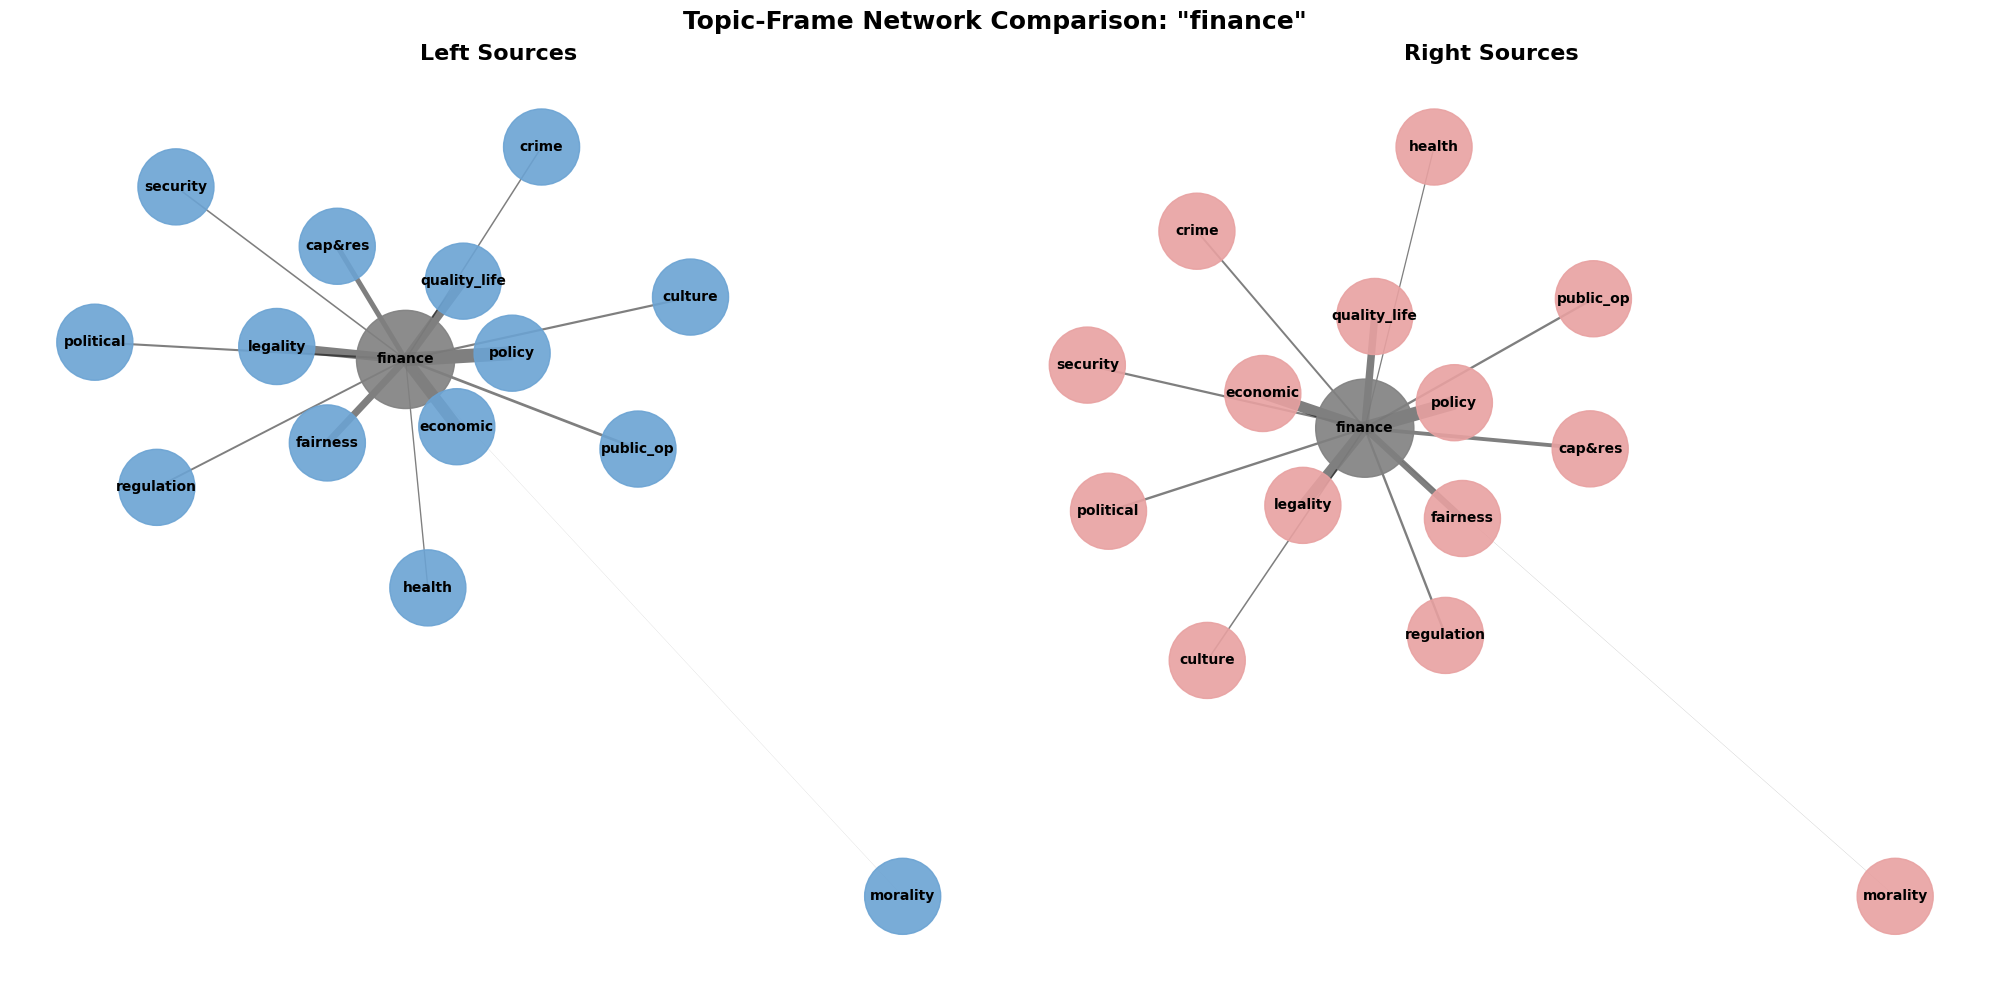

In [37]:
def plot_topic_frame_network_comparison(focus_topic):
    """
    Plot topic-frame networks for Left and Right side-by-side
    
    Parameters:
    focus_topic (str): The topic to focus on
    """
    import networkx as nx
    import matplotlib.pyplot as plt
    import numpy as np
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    for idx, (bias, df, frame_color) in enumerate([('Left', left_df, '#6BA3D3'), 
                                                     ('Right', right_df, '#E8A1A1')]):
        
        topic_df = df[df['topic_top1'] == focus_topic]
        
        if len(topic_df) == 0:
            axes[idx].text(0.5, 0.5, f'No articles found for "{focus_topic}"', 
                          ha='center', va='center', fontsize=14)
            axes[idx].set_title(f'{bias} Sources', fontsize=16, fontweight='bold')
            axes[idx].axis('off')
            continue
        
        # Count frame occurrences for this topic
        frame_counts = {}
        for _, row in topic_df.iterrows():
            vector = row['vector']
            
            if isinstance(vector, np.ndarray):
                vector = vector.tolist()
            
            for frame_idx, val in enumerate(vector):
                if val == 1:
                    frame_name = ordered_frame_names[frame_idx]
                    frame_counts[frame_name] = frame_counts.get(frame_name, 0) + 1
        
        # Create network graph
        G = nx.Graph()
        G.add_node(focus_topic, node_type='topic')
        
        # Add frame nodes and edges
        for frame, count in frame_counts.items():
            G.add_node(frame, node_type='frame')
            G.add_edge(focus_topic, frame, weight=count)
        
        # Layout
        pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
        
        # Node colors and sizes - grey center, colored frames
        node_colors = ['#808080' if G.nodes[node].get('node_type') == 'topic' else frame_color 
                       for node in G.nodes()]
        node_sizes = [5000 if G.nodes[node].get('node_type') == 'topic' else 3000 
                      for node in G.nodes()]
        
        # Draw nodes
        nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                               node_size=node_sizes, alpha=0.9, ax=axes[idx])
        
        # Draw edges
        edges = G.edges()
        weights = [G[u][v]['weight'] for u, v in edges]
        max_weight = max(weights) if weights else 1
        nx.draw_networkx_edges(G, pos, width=[10 * w/max_weight for w in weights], 
                               alpha=0.5, ax=axes[idx])
        
        # Draw labels
        nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=axes[idx])
        
        '''
        # Add edge labels (counts)
        edge_labels = {(u, v): f"{G[u][v]['weight']}" for u, v in edges}
        nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=9, ax=axes[idx])
        '''
        
        axes[idx].set_title(f'{bias} Sources', fontsize=16, fontweight='bold')
        axes[idx].axis('off')
    
    fig.suptitle(f'Topic-Frame Network Comparison: "{focus_topic}"', 
                 fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

plot_topic_frame_network_comparison('finance')

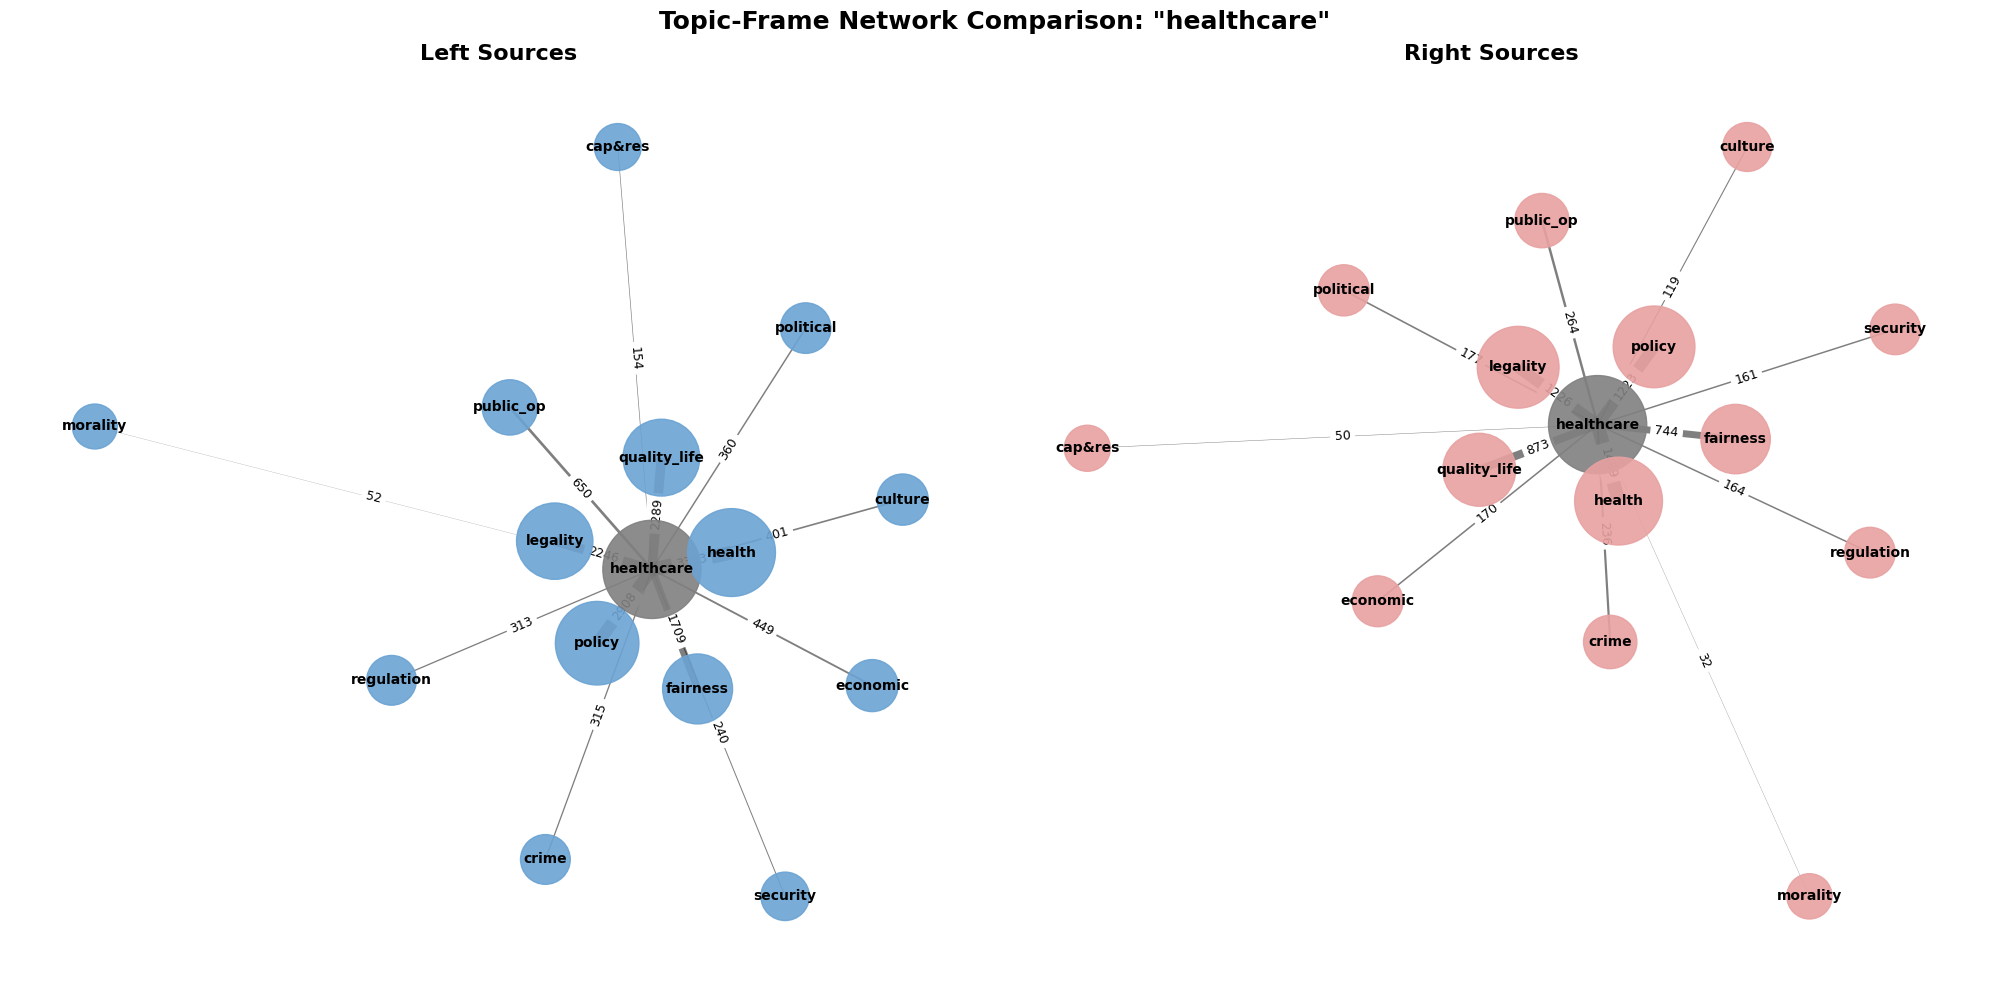

In [38]:
def plot_topic_frame_network_comparison(focus_topic):
    """
    Plot topic-frame networks for Left and Right side-by-side
    
    Parameters:
    focus_topic (str): The topic to focus on
    """
    import networkx as nx
    import matplotlib.pyplot as plt
    import numpy as np
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    for idx, (bias, df, frame_color) in enumerate([('Left', left_df, '#6BA3D3'), 
                                                     ('Right', right_df, '#E8A1A1')]):
        
        # Filter for the focus topic
        topic_df = df[df['topic_top1'] == focus_topic]
        
        if len(topic_df) == 0:
            axes[idx].text(0.5, 0.5, f'No articles found for "{focus_topic}"', 
                          ha='center', va='center', fontsize=14)
            axes[idx].set_title(f'{bias} Sources', fontsize=16, fontweight='bold')
            axes[idx].axis('off')
            continue
        
        # Count frame occurrences for this topic
        frame_counts = {}
        for _, row in topic_df.iterrows():
            vector = row['vector']
            
            if isinstance(vector, np.ndarray):
                vector = vector.tolist()
            
            for frame_idx, val in enumerate(vector):
                if val == 1:
                    frame_name = ordered_frame_names[frame_idx]
                    frame_counts[frame_name] = frame_counts.get(frame_name, 0) + 1
        
        # Create network graph
        G = nx.Graph()
        
        # Add topic node
        G.add_node(focus_topic, node_type='topic')
        
        # Add frame nodes and edges
        for frame, count in frame_counts.items():
            G.add_node(frame, node_type='frame', count=count)
            G.add_edge(focus_topic, frame, weight=count)
        
        # Layout
        pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
        
        # Node colors - grey center, colored frames
        node_colors = ['#808080' if G.nodes[node].get('node_type') == 'topic' else frame_color 
                       for node in G.nodes()]
        
        # Node sizes - scale frame nodes by their counts
        node_sizes = []
        for node in G.nodes():
            if G.nodes[node].get('node_type') == 'topic':
                node_sizes.append(5000)
            else:
                # Scale frame nodes by count (min 1000, max 4000)
                count = G.nodes[node].get('count', 1)
                max_count = max(frame_counts.values())
                scaled_size = 1000 + (count / max_count) * 3000
                node_sizes.append(scaled_size)
        
        # Draw nodes
        nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                               node_size=node_sizes, alpha=0.9, ax=axes[idx])
        
        # Draw edges
        edges = G.edges()
        weights = [G[u][v]['weight'] for u, v in edges]
        max_weight = max(weights) if weights else 1
        nx.draw_networkx_edges(G, pos, width=[10 * w/max_weight for w in weights], 
                               alpha=0.5, ax=axes[idx])
        
        # Draw labels
        nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=axes[idx])
        
        # Add edge labels (counts)
        edge_labels = {(u, v): f"{G[u][v]['weight']}" for u, v in edges}
        nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=9, ax=axes[idx])
        
        axes[idx].set_title(f'{bias} Sources', fontsize=16, fontweight='bold')
        axes[idx].axis('off')
    
    fig.suptitle(f'Topic-Frame Network Comparison: "{focus_topic}"', 
                 fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# Usage:
plot_topic_frame_network_comparison('healthcare')